# fastfuncsim Full Pipeline Demo

This notebook showcases all major fastfuncsim analysis tools in a single workflow:

1. **OLS GLM + ARMA autocorrelation correction** — design matrix inspection, beta/t-stat comparison
2. **HRF estimation** — per-voxel HRF selection from a library, spatial HRF variability
3. **GLMdenoise-style denoising** — noise pool PCA, CV curve, PC maps
4. **Whole-brain ICA** — task-correlated components, motion IC identification
5. **Ridge regression / single-trial betas** — per-voxel regularization, high vs low R² voxel comparison

**Key design principle:** Data is loaded once at the top. All subsequent analyses stream
voxel chunks to the GPU as needed — the full dataset stays in CPU RAM.

---
Edit the **Configuration** cell, then run all cells top-to-bottom (`Kernel → Restart & Run All`).

In [ ]:

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import torch

from fastfuncsim.afni_io import read_afni_design_matrix
from fastfuncsim.arma_glm import fit_glm_arma11

# fastfuncsim core
from fastfuncsim.cli_utils import (
    auto_polort,
    build_nuisance_per_run,
    compute_run_lengths,
    get_average_run_duration,
    load_and_preprocess_runs,
)
from fastfuncsim.denoise import fit_denoising_model
from fastfuncsim.design import convolve_hrf_microtime
from fastfuncsim.design_builder import (
    create_onset_matrix_microtime,
    parse_afni_timing_file,
    parse_durations,
)
from fastfuncsim.glm_core import fit_glm
from fastfuncsim.hrf import get_hrf_library, get_spmg1_hrf
from fastfuncsim.hrf_selection import fit_glm_hrf_library_with_xval
from fastfuncsim.ica import FastICA
from fastfuncsim.ica_tools import (
    apply_melodic_voxel_varnorm,
    apply_polort_projection,
    component_condition_correlations,
    estimate_ica_component_count,
)
from fastfuncsim.ridge import _fit_ridge_multiple_fracs, create_single_trial_design
from fastfuncsim.utils import get_device
from fastfuncsim.xval import (
    compute_r2_metric,
    generate_cv_splits,
    project_out_nuisance_per_run,
    single_trial_cv_helper,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print('Imports OK')

Imports OK


## Configuration
Edit the paths and parameters below to match your data.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# USER CONFIGURATION  ← Edit everything in this cell
# ─────────────────────────────────────────────────────────────────────────────

# Input fMRI run files (NIfTI or AFNI BRIK)
INPUT_FILES = [
    "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/ses-01_task-mvpsA_run01_final.nii",
    "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/ses-01_task-mvpsA_run02_final.nii",
    "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/ses-01_task-mvpsA_run03_final.nii",
    "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/ses-01_task-mvpsA_run04_final.nii",
    "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/ses-01_task-mvpsA_run05_final.nii",
    "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/ses-01_task-mvpsA_run06_final.nii",
    "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/ses-01_task-mvpsA_run07_final.nii",
    "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/ses-01_task-mvpsA_run08_final.nii",
    "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/ses-01_task-mvpsA_run09_final.nii",
]

# Brain mask (set to None to use all non-zero voxels)
MASK_FILE = "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/automask_min_ses-01_all.nii.gz"

# AFNI-format timing files, one per condition
# Each file: one row per run, space-separated onset times in seconds
ONSET_FILES = [
    "/home/logan/Dropbox/Projects/MovieTasks/code_movietasks/data_pilot/preproc/sub-pilot01/ses-01/timing_files/simple_2_type/ses01_times.prompt.txt",
    "/home/logan/Dropbox/Projects/MovieTasks/code_movietasks/data_pilot/preproc/sub-pilot01/ses-01/timing_files/simple_2_type/ses01_times.movie.txt",
]
CONDITION_LABELS = ["Prompt", "Movie"]  # must match ONSET_FILES length

# Stimulus duration in seconds (single value → same for all conditions)
DURATIONS = 5.0  # or a list: [2.0, 4.0]

# TR in seconds (None = read from NIfTI header)
TR = None

# Optional: concatenated motion/nuisance regressor file (AFNI .1D, all runs)
# Set to None to skip
ORTVEC_FILE = "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/step02_ses-01_task-mvpsA_dfile_rall.1D"  # e.g. "motion_params_all.1D"

# Microtime resolution in seconds (0.1 is standard throughout the pipeline)
DT = 0.1

# HRF library size for HRF estimation section
N_HRFS = 20

# Max noise PCs to evaluate in denoising
MAX_NOISE_PCS = 30

# Number of ICA components to extract (None = auto-estimate)
N_ICA_COMPS = None

# Ridge fraction grid: (start, end, step)
RIDGE_FRAC_GRID = (0.05, 1.0, 0.05)

# Chunk size for voxel streaming to GPU (tune if you hit OOM)
CHUNK_SIZE = 50_000

# ─────────────────────────────────────────────────────────────────────────────
device = get_device()
print(f'Device: {device}')
if device.type == 'cuda':
    mem_gb = torch.cuda.get_device_properties(device).total_memory / 1024**3
    print(f'  GPU memory: {mem_gb:.1f} GB')

Device: cuda
  GPU memory: 15.5 GB


## Data Loading
Runs once. All sections below reuse `data`, `task_design`, `nuisance_per_run`, etc.

In [5]:
# ── Load fMRI data ────────────────────────────────────────────────────────────
load_result = load_and_preprocess_runs(
    input_files=INPUT_FILES,
    tr=TR,
    mask_file=MASK_FILE,
    do_scale=True,   # percent signal change
    device=device,
    verbose=True,
)

data        = load_result.data          # (n_voxels, n_timepoints) on CPU
run_starts  = load_result.run_starts    # [0, run1_len, ...]
affine      = load_result.affine
vol_shape   = load_result.volume_shape  # (x, y, z)
voxel_sizes = load_result.voxel_sizes
tr          = load_result.tr
mask_flat   = load_result.mask_flat     # 1D bool, length = prod(vol_shape)
n_voxels    = load_result.n_voxels
n_timepoints= load_result.n_timepoints
n_runs      = load_result.n_runs

print(f'Data:       {data.shape}   dtype={data.dtype}')
print(f'Runs:       {n_runs}  run_starts={run_starts}')
print(f'TR:         {tr} s')
print(f'Vol shape:  {vol_shape}  voxel sizes={voxel_sizes} mm')


📂 Loading fMRI Data
  Volume shape: (87, 87, 115)
  Voxel sizes: (1.600000023841858, 1.600000023841858, 1.600000023841858) mm
  TR: 1.0 s
  Runs: 9
  Mask: /mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/automask_min_ses-01_all.nii.gz (311,522 voxels)


Loading fMRI runs:   0%|          | 0/9 [00:00<?, ?run/s]

Loading fMRI runs: 100%|██████████| 9/9 [00:44<00:00,  4.94s/run]



  Scaling to percent signal change...
Scaling to percent signal change (mean=100 per run)...
  Scaled 311,522 voxels × 9 runs
  ⚠️  Ceiling violations (>200.0): 97,332 timepoints (0.0096%)
      Affecting 1,997 voxels (0.64%)
    ⚠️  97332 voxels had scaling violations

  Data shape: torch.Size([311522, 3240]) (n_voxels × n_timepoints)
  Device: cuda

Data:       torch.Size([311522, 3240])   dtype=torch.float32
Runs:       9  run_starts=[0, 360, 720, 1080, 1440, 1800, 2160, 2520, 2880]
TR:         1.0 s
Vol shape:  (87, 87, 115)  voxel sizes=(1.600000023841858, 1.600000023841858, 1.600000023841858) mm


In [8]:
# ── Auto-determine polynomial order ─────────────────────────────────────────
run_lengths       = compute_run_lengths(run_starts, n_timepoints)
avg_run_duration  = get_average_run_duration(run_lengths, tr)
polort            = auto_polort(avg_run_duration, formula='afni')
print(f'Polort: {polort}  (avg run = {avg_run_duration/60:.1f} min)')

# ── Build nuisance regressors ────────────────────────────────────────────────
ortvec_files = [(ORTVEC_FILE, 'motion')] if ORTVEC_FILE else None

nuisance_per_run = build_nuisance_per_run(
    run_starts   = run_starts,
    n_timepoints = n_timepoints,
    polort       = polort,
    device       = torch.device('cpu'),   # keep on CPU
    ortvec_files = ortvec_files,
    verbose      = True,
)

# Block-diagonal concatenation for full-data GLM  (n_timepoints, n_nuisance_total)
nuisance_block_diag = torch.block_diag(*nuisance_per_run)
n_nuisance_cols     = nuisance_block_diag.shape[1]
print(f'Nuisance block-diag: {nuisance_block_diag.shape}')

# ── Parse onset files & build task design ───────────────────────────────────
# DURATIONS: normalise to a list of floats, one per condition
dur_list = ([DURATIONS] * len(ONSET_FILES)
            if isinstance(DURATIONS, (int, float))
            else list(DURATIONS))
stim_durations = parse_durations(
    [str(d) for d in dur_list],
    n_conditions   = len(ONSET_FILES),
    condition_labels = CONDITION_LABELS,
)

# Parse timing files  → all_onsets[cond][run] = np.ndarray of onset times (s)
all_onsets = [parse_afni_timing_file(f) for f in ONSET_FILES]

# Canonical HRF at microtime resolution
canonical_hrf = get_spmg1_hrf(microtime_dt=DT, device=torch.device('cpu'))

# Microtime onset matrix  (n_microtime, n_conditions)
onset_matrix = create_onset_matrix_microtime(
    all_onsets     = all_onsets,
    run_starts     = run_starts,
    tr             = tr,
    n_timepoints   = n_timepoints,
    microtime_dt   = DT,
    stim_durations = stim_durations,
    device         = torch.device('cpu'),
)

# Convolve → task design  (n_timepoints, n_conditions)
task_design = convolve_hrf_microtime(
    onsets_microtime = onset_matrix,
    hrf              = canonical_hrf,
    n_timepoints     = n_timepoints,
    tr               = tr,
    microtime_dt     = DT,
    run_starts       = run_starts,
    device           = torch.device('cpu'),
)
n_conditions = task_design.shape[1]
print(f'Task design: {task_design.shape}  conditions={CONDITION_LABELS}')

Polort: 3  (avg run = 6.0 min)
  Loaded ortvec: /mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/global_proc/step02_ses-01_task-mvpsA_dfile_rall.1D (label=motion, shape=torch.Size([3240, 6]))
  Run 0: nuisance shape = torch.Size([360, 10])
  Run 1: nuisance shape = torch.Size([360, 10])
  Run 2: nuisance shape = torch.Size([360, 10])
  Run 3: nuisance shape = torch.Size([360, 10])
  Run 4: nuisance shape = torch.Size([360, 10])
  Run 5: nuisance shape = torch.Size([360, 10])
  Run 6: nuisance shape = torch.Size([360, 10])
  Run 7: nuisance shape = torch.Size([360, 10])
  Run 8: nuisance shape = torch.Size([360, 10])
Nuisance block-diag: torch.Size([3240, 90])
Task design: torch.Size([3240, 2])  conditions=['Prompt', 'Movie']


---
## Section 1 — OLS GLM & ARMA Autocorrelation Correction

**OLS** (Ordinary Least Squares) gives the fastest beta estimates but ignores temporal
autocorrelation → inflated t-statistics. **ARMA(1,1)** models the residual autocorrelation
with REML-estimated per-voxel (a, b) parameters and returns corrected t-statistics.

/tmp/ipykernel_2345401/283505570.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


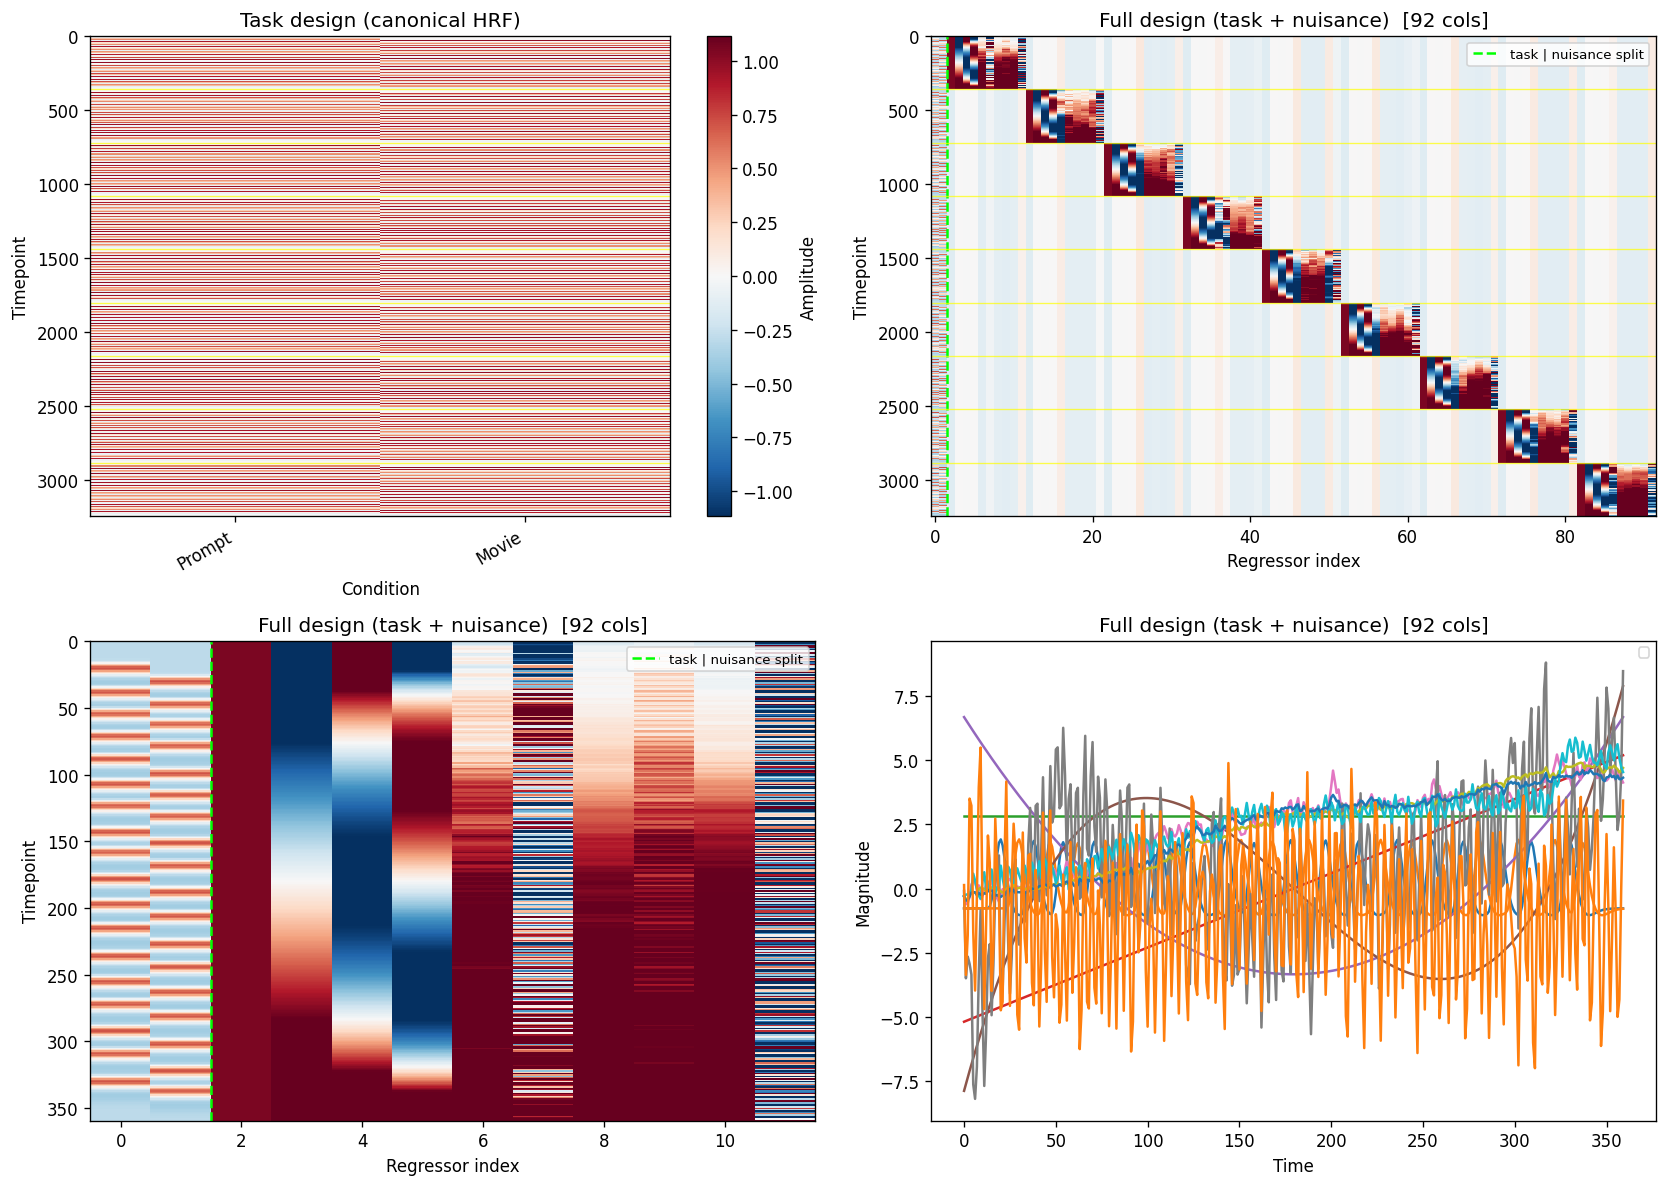

Task cols: 0–1   Nuisance cols: 2–91


In [72]:
# ── Design matrix inspection ─────────────────────────────────────────────────
full_design = torch.cat([task_design, nuisance_block_diag], dim=1)  # for display

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Task design (all runs)
ax = axes[0,0]
td_np = task_design.numpy()
im = ax.imshow(td_np, aspect='auto', cmap='RdBu_r',
               vmin=-td_np.std()*3, vmax=td_np.std()*3,
               interpolation='nearest')
ax.set_title('Task design (canonical HRF)')
ax.set_xlabel('Condition')
ax.set_ylabel('Timepoint')
ax.set_xticks(range(n_conditions))
ax.set_xticklabels(CONDITION_LABELS, rotation=30, ha='right')
for rs in run_starts[1:]:  # run boundary lines
    ax.axhline(rs - 0.5, color='yellow', lw=0.8, alpha=0.7)
plt.colorbar(im, ax=ax, label='Amplitude')

# Full design including nuisance
ax = axes[0,1]
fd_np = full_design.numpy()
fd_norm = (fd_np - fd_np.mean(0)) / (fd_np.std(0) + 1e-8)
ax.imshow(fd_norm, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3, interpolation='nearest')
ax.set_title(f'Full design (task + nuisance)  [{full_design.shape[1]} cols]')
ax.set_xlabel('Regressor index')
ax.set_ylabel('Timepoint')
ax.axvline(n_conditions - 0.5, color='lime', lw=1.5, linestyle='--',
           label='task | nuisance split')
for rs in run_starts[1:]:
    ax.axhline(rs - 0.5, color='yellow', lw=0.8, alpha=0.7)
ax.legend(fontsize=8)

# Full design, zoomed in on first run. 
ax = axes[1,0]
fd_np = full_design.numpy()
fd_norm = (fd_np - fd_np.mean(0)) / (fd_np.std(0) + 1e-8)
ax.imshow(fd_norm[run_starts[0]:run_starts[1],0:12], aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3, interpolation='nearest')
ax.set_title(f'Full design (task + nuisance)  [{full_design.shape[1]} cols]')
ax.set_xlabel('Regressor index')
ax.set_ylabel('Timepoint')
ax.axvline(n_conditions - 0.5, color='lime', lw=1.5, linestyle='--',
           label='task | nuisance split')
ax.legend(fontsize=8)

# Full design, as a line plot instead. 
# Full design including nuisance
ax = axes[1,1]
fd_np = full_design.numpy()
fd_norm = (fd_np - fd_np.mean(0)) / (fd_np.std(0) + 1e-8)
ax.plot(fd_norm[run_starts[0]:run_starts[1],0:12])
ax.set_title(f'Full design (task + nuisance)  [{full_design.shape[1]} cols]')
ax.set_xlabel('Time')
ax.set_ylabel('Magnitude')

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f'Task cols: 0–{n_conditions-1}   Nuisance cols: {n_conditions}–{full_design.shape[1]-1}')

Load in the AFNi design that we just made and see if these are in agreement - they should be more or less similar, right?


1. Reading AFNI design matrix...
   Design shape: (3240, 92)
   TR: 1.0s
   Stimulus labels: ['Prompt', 'Movie']


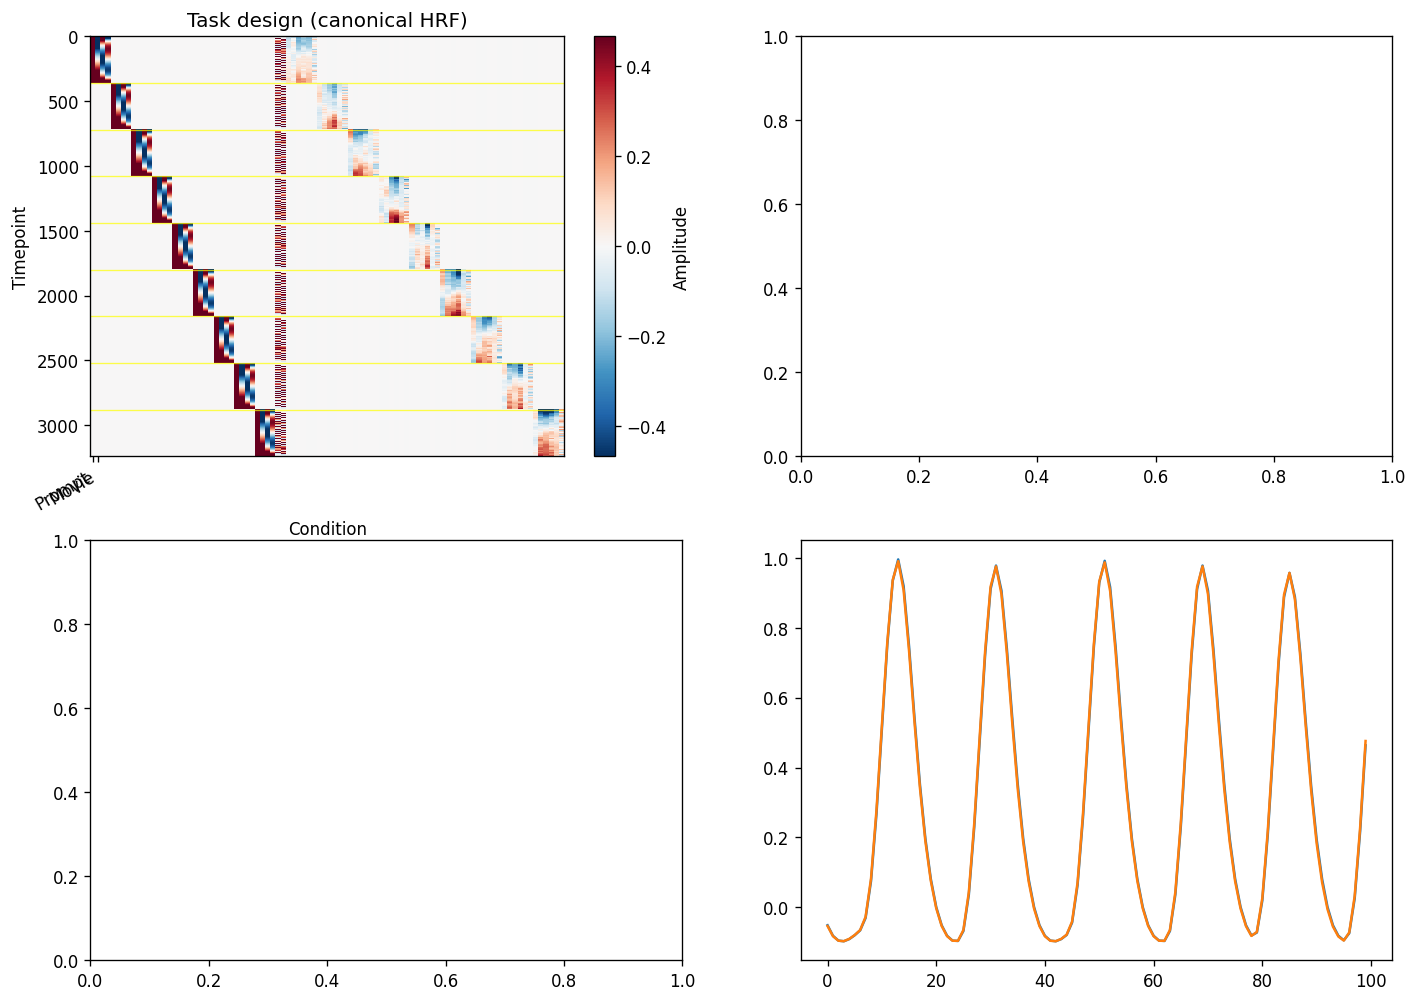

In [55]:
# we have a tool to load and parse and AFNI design. 
design_file = "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/afni_reml/rm_test_X.xmat.1D"
print("\n1. Reading AFNI design matrix...")
design_info = read_afni_design_matrix(design_file)

print(f"   Design shape: {design_info['matrix'].shape}")
print(f"   TR: {design_info['tr']}s")
print(f"   Stimulus labels: {design_info['stim_labels']}")

# ── Design matrix inspection ─────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Task design (all runs)
ax = axes[0,0]
afni_full_design = design_info["matrix"]
im = ax.imshow(afni_full_design, aspect='auto', cmap='RdBu_r',
               vmin=-afni_full_design.std()*3, vmax=afni_full_design.std()*3,
               interpolation='nearest')
ax.set_title('Task design (canonical HRF)')
ax.set_xlabel('Condition')
ax.set_ylabel('Timepoint')
ax.set_xticks(range(n_conditions))
ax.set_xticklabels(CONDITION_LABELS, rotation=30, ha='right')
for rs in run_starts[1:]:  # run boundary lines
    ax.axhline(rs - 0.5, color='yellow', lw=0.8, alpha=0.7)
plt.colorbar(im, ax=ax, label='Amplitude')

ax = axes[1,0]
plt.plot(afni_full_design[2680:2780,37])
plt.plot(fd_np[2680:2780,1])
# # Extract stimulus columns only
# print("\n2. Extracting stimulus columns...")
# stim_design = ffs.extract_stimulus_columns(design_info, device=device)
# print(f"   Stimulus design shape: {stim_design.shape}")

# # Extract nuisance columns
# nuisance_design = ffs.extract_nuisance_columns(design_info, device=device)
# print(f"   Nuisance design shape: {nuisance_design.shape}")

In [18]:
# ── OLS GLM ──────────────────────────────────────────────────────────────────
print('Fitting OLS GLM...')
ols = fit_glm(
    data                  = data,
    design                = task_design,
    tr                    = tr,
    max_poly_degree       = -1,         # polynomials already in nuisance_block_diag
    extra_regressors      = nuisance_block_diag,
    want_residuals        = False,
    device                = device,
    chunk_size            = CHUNK_SIZE,
    preload_data_to_device= False,      # stream from CPU
    verbose               = True,
)

ols_betas  = ols.betas[:, :n_conditions].cpu()   # (n_voxels, n_conditions)
ols_tstats = ols.tstats[:, :n_conditions].cpu() if ols.tstats is not None else None
ols_r2     = ols.r2.cpu()

print(f'OLS  R² — mean={ols_r2.mean():.3f}  median={ols_r2.median():.3f}')

Fitting OLS GLM...
Fitting GLM: 311522 voxels, 1 runs, 2 task regressors
Processing in chunks of 50000 voxels
Streaming from CPU (reduced chunk size for memory safety)


Processing voxel chunks: 100%|██████████| 7/7 [00:08<00:00,  1.22s/chunk]


GLM complete. Mean R² = 0.457
OLS  R² — mean=0.457  median=0.435


In [19]:
# ── ARMA(1,1) GLM ─────────────────────────────────────────────────────────────
# ARMA needs the FULL design (task + nuisance concatenated)
print('Fitting ARMA(1,1) GLM (this takes a few minutes)...')
arma = fit_glm_arma11(
    data          = data,
    design        = full_design,   # (n_timepoints, n_task + n_nuisance)
    tr            = tr,
    device        = device,
    verbose       = True,
)

arma_betas  = arma.betas[:, :n_conditions].cpu()
arma_tstats = arma.tstats[:, :n_conditions].cpu() if arma.tstats is not None else None
arma_r2     = arma.r2.cpu()
arma_params = arma.arma_params.cpu() if arma.arma_params is not None else None  # (n_voxels, 2)

print(f'ARMA R² — mean={arma_r2.mean():.3f}  median={arma_r2.median():.3f}')
if arma_params is not None:
    print(f'ARMA a — mean={arma_params[:, 0].mean():.3f}  b — mean={arma_params[:, 1].mean():.3f}')

Fitting ARMA(1,1) GLM (this takes a few minutes)...
Grid memory: 6223.4 MiB (151 pairs)
Strategy: Full grid precomputation (AFNI approach)
Adjusted batch size: 1,355 voxels (grid + batches fit in GPU)
ARMA(1,1) GLM Fit
  Voxels: 311,522
  Timepoints: 3240
  Regressors: 92
  Per-voxel estimation: True
  Batch size: 1,355
Processing 230 batches of 1,355 voxels...
Pre-computing REML grid (Cholesky factorizations)...
  Using CPU Cholesky (grid: 47.9GB > 14.6GB available)
  Building ALL covariance matrices (vectorized)...
    Initial grid: 10 a × 20 b = 200 combinations
  ✓ Built 151 covariance matrices (filtered 49 with λ ≤ 0)
  Computing ALL Cholesky factorizations (batched on CPU (recommended))...
    [DEBUG] R_batch shape: torch.Size([151, 3240, 3240]), device: cpu, dtype: torch.float32
    [DEBUG] Target device: cuda, cholesky_on_cpu: True
    [DEBUG] PyTorch threads: 6
    [DEBUG] Entering Cholesky computation...
    [DEBUG] In cholesky_on_cpu branch
    [DEBUG] Checking chunking: dev

ARMA(1,1) groups:   0%|          | 0/94 [00:00<?, ?group/s]

  Persistent GPU tensor 'L_inv': 0.04 GB (already allocated)
  Persistent GPU tensor 'X_w': 0.00 GB (already allocated)
  Persistent GPU tensor 'design': 0.00 GB (already allocated)
  ✓ Batch fits: 0.09 GB needed < 2.68 GB available


ARMA(1,1) groups:   1%|          | 1/94 [00:00<00:32,  2.88group/s]


  Group 1 timing (15,468 voxels, 12 batches):
    QR setup:       0.00s (once per group)
    Prewhiten:      0.02s (0.001s/batch)
    QR solve:       0.00s (0.000s/batch)
    Statistics:     0.01s (0.001s/batch)
    Total:          0.03s


  Group 2 timing (844 voxels, 1 batches):
    QR setup:       0.00s (once per group)
    Prewhiten:      0.00s (0.001s/batch)
    QR solve:       0.00s (0.000s/batch)
    Statistics:     0.00s (0.001s/batch)
    Total:          0.00s



ARMA(1,1) groups:   5%|▌         | 5/94 [00:00<00:11,  7.95group/s]


  Group 3 timing (5,549 voxels, 5 batches):
    QR setup:       0.00s (once per group)
    Prewhiten:      0.00s (0.001s/batch)
    QR solve:       0.00s (0.000s/batch)
    Statistics:     0.00s (0.000s/batch)
    Total:          0.01s



ARMA(1,1) groups: 100%|██████████| 94/94 [00:09<00:00,  9.70group/s]



✓ Processed all 94 unique (a,b) groups
  Total voxels processed: 311,522

Complete!
  Mean (a, b): (0.517, -0.336)
  Mean λ: 0.216
  Mean R²: 0.450
  Mean |t|: 4.471
ARMA R² — mean=0.450  median=0.430
ARMA a — mean=0.517  b — mean=-0.336


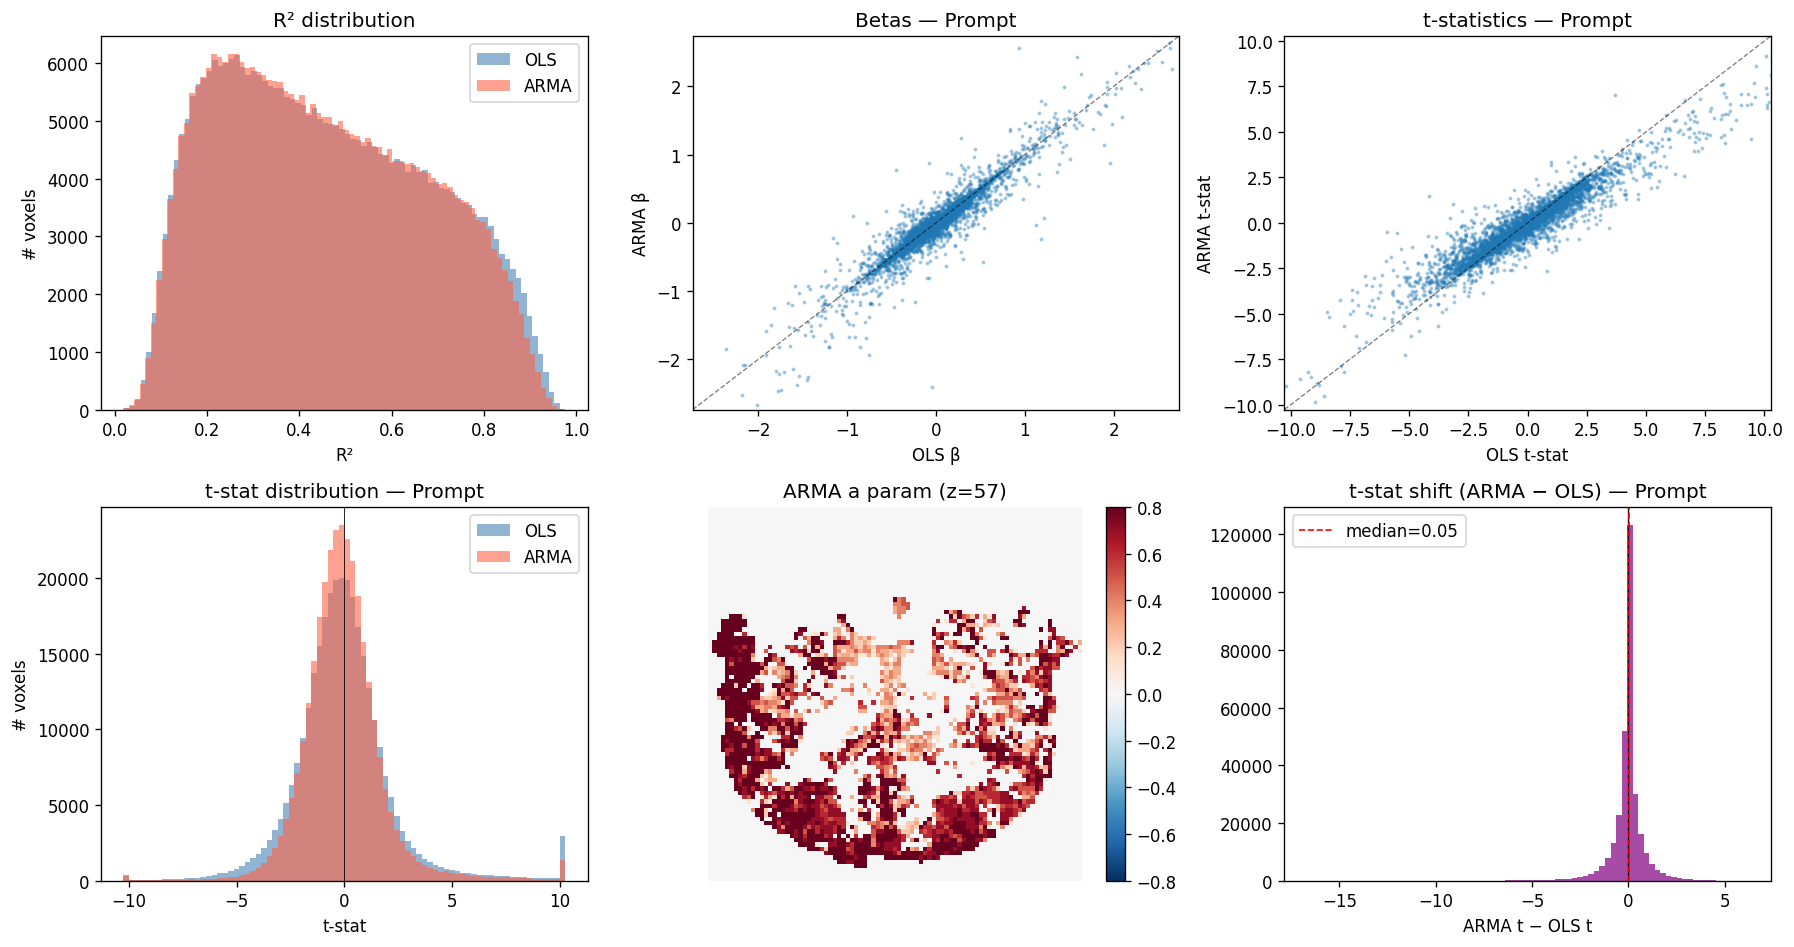

In [20]:
# ── OLS vs ARMA comparison ───────────────────────────────────────────────────
# Tunable: change COND_IDX to inspect any condition
COND_IDX = 0
cond_label = CONDITION_LABELS[COND_IDX]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# R² comparison
ax = axes[0, 0]
ax.hist(ols_r2.numpy(), bins=80, alpha=0.6, label='OLS', color='steelblue')
ax.hist(arma_r2.numpy(), bins=80, alpha=0.6, label='ARMA', color='tomato')
ax.set_xlabel('R²'); ax.set_ylabel('# voxels')
ax.set_title('R² distribution')
ax.legend()

# Beta comparison (scatter)
ax = axes[0, 1]
subsample = slice(None, None, max(1, n_voxels // 5000))  # max 5000 pts
ax.scatter(ols_betas[subsample, COND_IDX].numpy(),
           arma_betas[subsample, COND_IDX].numpy(),
           s=2, alpha=0.3, rasterized=True)
lim = max(abs(ols_betas[:, COND_IDX]).quantile(0.99).item(),
           abs(arma_betas[:, COND_IDX]).quantile(0.99).item())
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('OLS β'); ax.set_ylabel('ARMA β')
ax.set_title(f'Betas — {cond_label}')

# t-stat comparison
ax = axes[0, 2]
if ols_tstats is not None and arma_tstats is not None:
    ax.scatter(ols_tstats[subsample, COND_IDX].numpy(),
               arma_tstats[subsample, COND_IDX].numpy(),
               s=2, alpha=0.3, rasterized=True)
    tlim = max(abs(ols_tstats[:, COND_IDX]).quantile(0.99).item(),
               abs(arma_tstats[:, COND_IDX]).quantile(0.99).item())
    ax.set_xlim(-tlim, tlim); ax.set_ylim(-tlim, tlim)
    ax.plot([-tlim, tlim], [-tlim, tlim], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlabel('OLS t-stat'); ax.set_ylabel('ARMA t-stat')
    ax.set_title(f't-statistics — {cond_label}')
else:
    ax.text(0.5, 0.5, 't-stats not computed', ha='center', va='center',
            transform=ax.transAxes)

# t-stat distribution comparison
ax = axes[1, 0]
if ols_tstats is not None and arma_tstats is not None:
    ols_t_np   = ols_tstats[:, COND_IDX].numpy()
    arma_t_np  = arma_tstats[:, COND_IDX].numpy()
    clip = np.percentile(np.abs(ols_t_np), 99)
    ax.hist(np.clip(ols_t_np,  -clip, clip), bins=80, alpha=0.6, label='OLS',  color='steelblue')
    ax.hist(np.clip(arma_t_np, -clip, clip), bins=80, alpha=0.6, label='ARMA', color='tomato')
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('t-stat'); ax.set_ylabel('# voxels')
    ax.set_title(f't-stat distribution — {cond_label}')
    ax.legend()

# ARMA a parameter map (one slice)
ax = axes[1, 1]
if arma_params is not None:
    a_map = np.zeros(int(np.prod(vol_shape)), dtype=np.float32)
    if mask_flat is not None:
        a_map[mask_flat] = arma_params[:, 0].numpy()
    else:
        a_map = arma_params[:, 0].numpy()
    a_vol = a_map.reshape(vol_shape)
    mid_z = vol_shape[2] // 2
    im = ax.imshow(a_vol[:, :, mid_z].T, origin='lower', cmap='RdBu_r',
                   vmin=-0.8, vmax=0.8)
    plt.colorbar(im, ax=ax)
    ax.set_title(f'ARMA a param (z={mid_z})')
    ax.axis('off')

# OLS vs ARMA t-stat difference
ax = axes[1, 2]
if ols_tstats is not None and arma_tstats is not None:
    diff = (arma_tstats[:, COND_IDX] - ols_tstats[:, COND_IDX]).numpy()
    ax.hist(diff, bins=80, color='purple', alpha=0.7)
    ax.axvline(0, color='k', lw=0.8)
    ax.axvline(np.median(diff), color='r', lw=1, linestyle='--', label=f'median={np.median(diff):.2f}')
    ax.set_xlabel('ARMA t − OLS t')
    ax.set_title(f't-stat shift (ARMA − OLS) — {cond_label}')
    ax.legend()

plt.tight_layout()
plt.show()

In [26]:
# We need to compare with AFNI output at this point. We can load that in directly. 
import nibabel as nib

# /mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/afni_reml

# AFNI_OLS.nii
# AFNI_REML.nii
# AFNI_REMLVar.nii

afni_ols_file = "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/afni_reml/AFNI_OLS.nii"
afni_ols_img = nib.load(afni_ols_file)
afni_ols_data = afni_ols_img.get_fdata()
print(f'AFNI OLS data shape: {afni_ols_data.shape}')
# Thats Fstat, Prompt Beta, Prompt Tstat, Movie Beta, Movie Tstat in the 4th dim.  We want 1 and 3 for beta comparison, and 2 and 4 for t-stat comparison.

# Load in the REML file, and the REMLVar file as well, 
afni_reml_file = "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/afni_reml/AFNI_REML.nii"
afni_reml_img = nib.load(afni_reml_file)
afni_reml_data = afni_reml_img.get_fdata()
print(f'AFNI REML data shape: {afni_reml_data.shape}')
afni_remlvar_file = "/mnt/belegost/Data/nii_data/PROJECT_TASKFORCE/derivatives/afni_reml/AFNI_REMLVar.nii"
afni_remlvar_img = nib.load(afni_remlvar_file)
afni_remlvar_data = afni_remlvar_img.get_fdata()
print(f'AFNI REMLVar data shape: {afni_remlvar_data.shape}')
# Remlvar is a,b,lam and we don't care about the others. 
# we can also use the mask we loaded in here. 

# Lets mask these three datasets
mask_flat_np = np.asarray(mask_flat, dtype=bool).reshape(-1) if mask_flat is not None else np.ones(int(np.prod(vol_shape)), dtype=bool)

def _flatten_afni_stats(arr):
	"""Convert AFNI stat volume to (n_voxels, n_stats)."""
	arr_np = np.asarray(arr)
	if arr_np.ndim == 3:
		arr_np = arr_np[..., None]
	return arr_np.reshape(-1, int(np.prod(arr_np.shape[3:])))

afni_ols_flat = _flatten_afni_stats(afni_ols_data)
afni_reml_flat = _flatten_afni_stats(afni_reml_data)
afni_remlvar_flat = _flatten_afni_stats(afni_remlvar_data)

if mask_flat_np.size != afni_ols_flat.shape[0]:
	raise ValueError(f"Mask size ({mask_flat_np.size}) does not match AFNI voxel count ({afni_ols_flat.shape[0]}).")

afni_ols_betas = afni_ols_flat[mask_flat_np][:, [1, 3]]     # (n_voxels, n_conditions)
afni_ols_tstats = afni_ols_flat[mask_flat_np][:, [2, 4]]    # (n_voxels, n_conditions)
afni_reml_betas = afni_reml_flat[mask_flat_np][:, [1, 3]]   # (n_voxels, n_conditions)
afni_reml_tstats = afni_reml_flat[mask_flat_np][:, [2, 4]]  # (n_voxels, n_conditions)
afni_reml_a = afni_remlvar_flat[mask_flat_np][:, 0]         # (n_voxels,)
afni_reml_b = afni_remlvar_flat[mask_flat_np][:, 1]         # (n_voxels,)


AFNI OLS data shape: (87, 87, 115, 1, 5)
AFNI REML data shape: (87, 87, 115, 1, 5)
AFNI REMLVar data shape: (87, 87, 115, 1, 6)


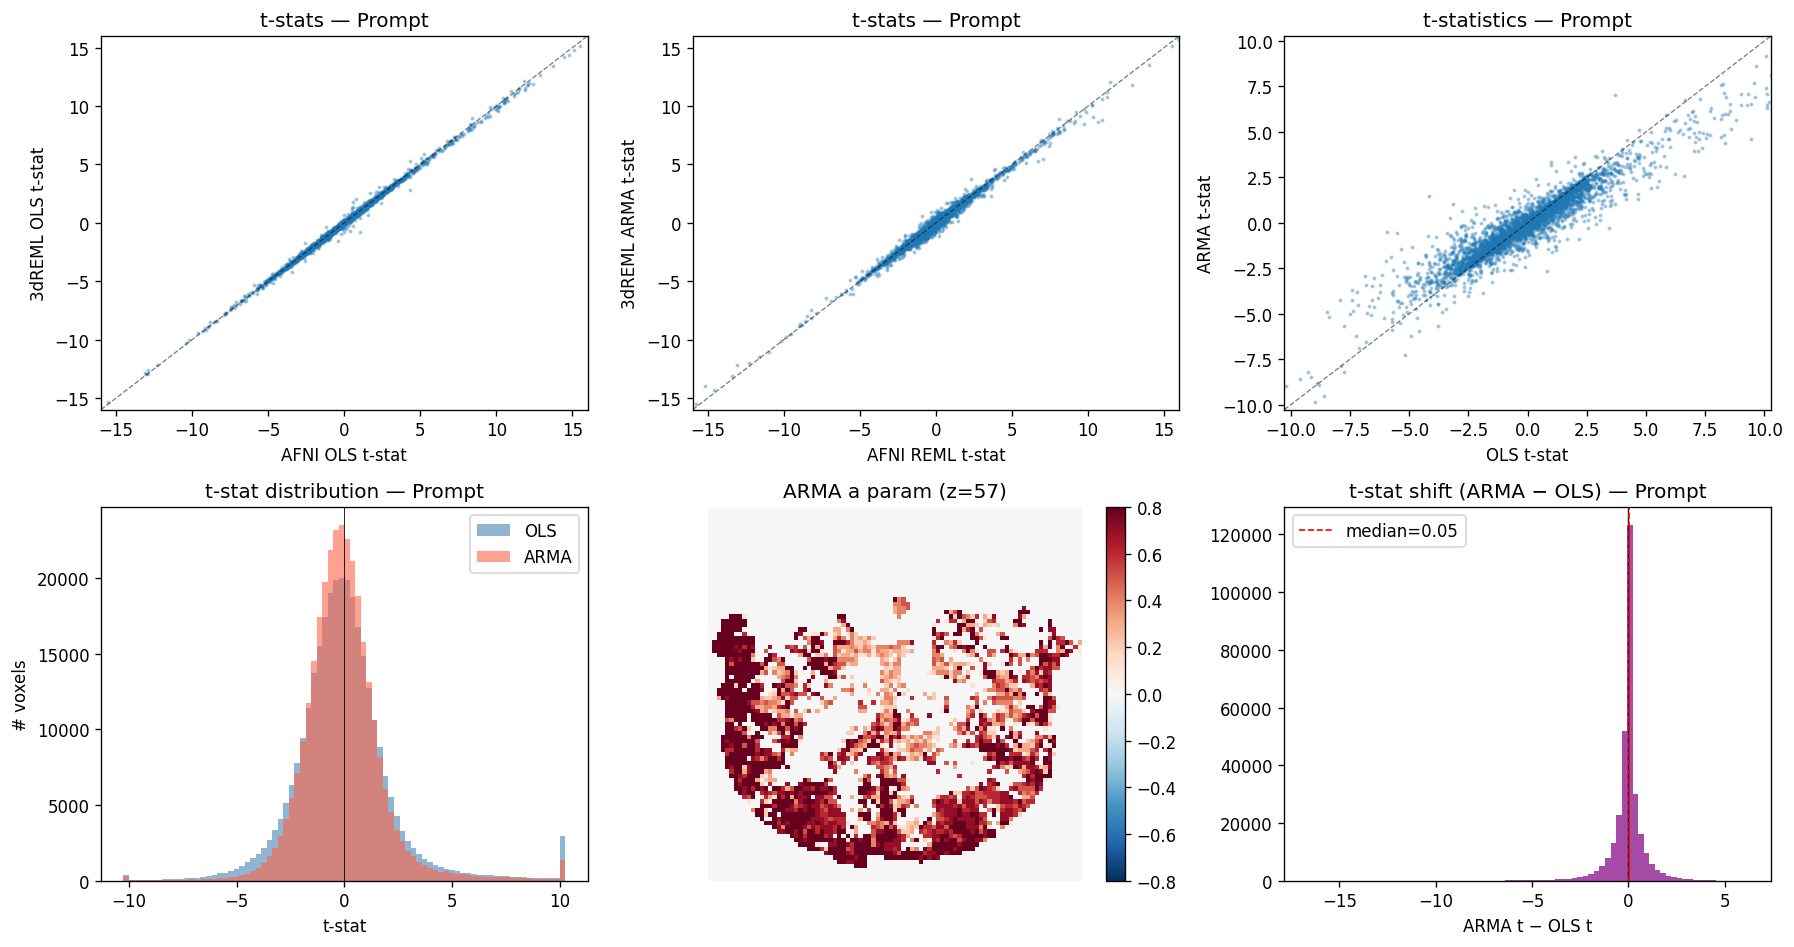

In [34]:
# ── AFNI vs Code comparison ───────────────────────────────────────────────────
# Tunable: change COND_IDX to inspect any condition
COND_IDX = 0
cond_label = CONDITION_LABELS[COND_IDX]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

lim_tstat = 16
# Tstat
ax = axes[0, 0]
subsample = slice(None, None, max(1, n_voxels // 5000))  # max 5000 pts
ax.scatter(ols_tstats[subsample, COND_IDX].numpy(),
           afni_ols_tstats[subsample, COND_IDX],
           s=2, alpha=0.3, rasterized=True)

ax.set_xlim(-lim_tstat, lim_tstat); ax.set_ylim(-lim_tstat, lim_tstat)
ax.plot([-lim_tstat, lim_tstat], [-lim_tstat, lim_tstat], 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('AFNI OLS t-stat'); ax.set_ylabel('3dREML OLS t-stat')
ax.set_title(f't-stats — {cond_label}')

ax = axes[0, 1]
subsample = slice(None, None, max(1, n_voxels // 5000))  # max 5000 pts
ax.scatter(arma_tstats[subsample, COND_IDX].numpy(),
           afni_reml_tstats[subsample, COND_IDX],
           s=2, alpha=0.3, rasterized=True)

ax.set_xlim(-lim_tstat, lim_tstat); ax.set_ylim(-lim_tstat, lim_tstat)
ax.plot([-lim_tstat, lim_tstat], [-lim_tstat, lim_tstat], 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('AFNI REML t-stat'); ax.set_ylabel('3dREML ARMA t-stat')
ax.set_title(f't-stats — {cond_label}')

# # Beta comparison (scatter)
# ax = axes[0, 1]
# subsample = slice(None, None, max(1, n_voxels // 5000))  # max 5000 pts
# ax.scatter(ols_betas[subsample, COND_IDX].numpy(),
#            arma_betas[subsample, COND_IDX].numpy(),
#            s=2, alpha=0.3, rasterized=True)
# lim = max(abs(ols_betas[:, COND_IDX]).quantile(0.99).item(),
#            abs(arma_betas[:, COND_IDX]).quantile(0.99).item())
# ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
# ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, alpha=0.5)
# ax.set_xlabel('AFNI β'); ax.set_ylabel('3dREML β')
# ax.set_title(f'Betas — {cond_label}')

# t-stat comparison
ax = axes[0, 2]
if ols_tstats is not None and arma_tstats is not None:
    ax.scatter(ols_tstats[subsample, COND_IDX].numpy(),
               arma_tstats[subsample, COND_IDX].numpy(),
               s=2, alpha=0.3, rasterized=True)
    tlim = max(abs(ols_tstats[:, COND_IDX]).quantile(0.99).item(),
               abs(arma_tstats[:, COND_IDX]).quantile(0.99).item())
    ax.set_xlim(-tlim, tlim); ax.set_ylim(-tlim, tlim)
    ax.plot([-tlim, tlim], [-tlim, tlim], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlabel('OLS t-stat'); ax.set_ylabel('ARMA t-stat')
    ax.set_title(f't-statistics — {cond_label}')
else:
    ax.text(0.5, 0.5, 't-stats not computed', ha='center', va='center',
            transform=ax.transAxes)

# t-stat distribution comparison
ax = axes[1, 0]
if ols_tstats is not None and arma_tstats is not None:
    ols_t_np   = ols_tstats[:, COND_IDX].numpy()
    arma_t_np  = arma_tstats[:, COND_IDX].numpy()
    clip = np.percentile(np.abs(ols_t_np), 99)
    ax.hist(np.clip(ols_t_np,  -clip, clip), bins=80, alpha=0.6, label='OLS',  color='steelblue')
    ax.hist(np.clip(arma_t_np, -clip, clip), bins=80, alpha=0.6, label='ARMA', color='tomato')
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('t-stat'); ax.set_ylabel('# voxels')
    ax.set_title(f't-stat distribution — {cond_label}')
    ax.legend()

# ARMA a parameter map (one slice)
ax = axes[1, 1]
if arma_params is not None:
    a_map = np.zeros(int(np.prod(vol_shape)), dtype=np.float32)
    if mask_flat is not None:
        a_map[mask_flat] = arma_params[:, 0].numpy()
    else:
        a_map = arma_params[:, 0].numpy()
    a_vol = a_map.reshape(vol_shape)
    mid_z = vol_shape[2] // 2
    im = ax.imshow(a_vol[:, :, mid_z].T, origin='lower', cmap='RdBu_r',
                   vmin=-0.8, vmax=0.8)
    plt.colorbar(im, ax=ax)
    ax.set_title(f'ARMA a param (z={mid_z})')
    ax.axis('off')

# OLS vs ARMA t-stat difference
ax = axes[1, 2]
if ols_tstats is not None and arma_tstats is not None:
    diff = (arma_tstats[:, COND_IDX] - ols_tstats[:, COND_IDX]).numpy()
    ax.hist(diff, bins=80, color='purple', alpha=0.7)
    ax.axvline(0, color='k', lw=0.8)
    ax.axvline(np.median(diff), color='r', lw=1, linestyle='--', label=f'median={np.median(diff):.2f}')
    ax.set_xlabel('ARMA t − OLS t')
    ax.set_title(f't-stat shift (ARMA − OLS) — {cond_label}')
    ax.legend()

plt.tight_layout()
plt.show()

---
## Section 2 — HRF Estimation

Each voxel may have a different hemodynamic lag. `fit_glm_hrf_library_with_xval` evaluates a
library of `N_HRFS` candidate HRFs via leave-one-run-out CV and selects the best per voxel.

HRF library: torch.Size([20, 320])


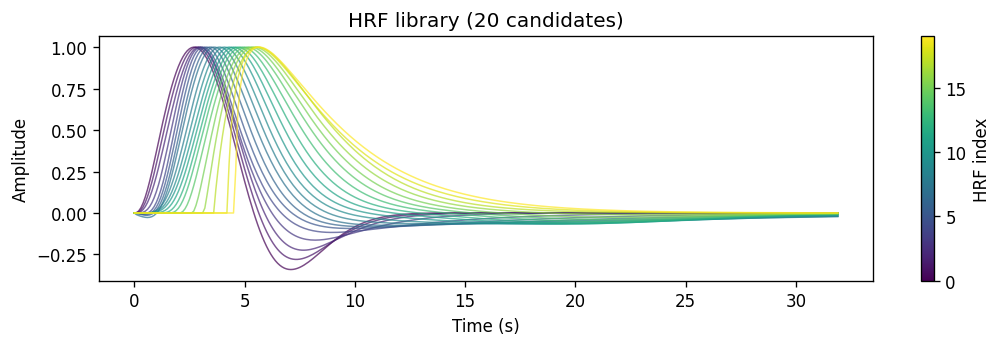

In [56]:
# ── Build HRF library ─────────────────────────────────────────────────────────
hrf_library = get_hrf_library(
    mode         = 'library',
    microtime_dt = DT,
    n_hrfs       = N_HRFS,
    device       = torch.device('cpu'),
)  # (N_HRFS, n_hrf_timepoints)
print(f'HRF library: {hrf_library.shape}')

# Quick look at the library
t_hrf = np.arange(hrf_library.shape[1]) * DT
fig, ax = plt.subplots(figsize=(9, 3))
cmap = plt.cm.viridis(np.linspace(0, 1, N_HRFS))
for i, hrf in enumerate(hrf_library.numpy()):
    ax.plot(t_hrf, hrf, color=cmap[i], lw=0.9, alpha=0.7)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
ax.set_title(f'HRF library ({N_HRFS} candidates)')
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(0, N_HRFS-1))
plt.colorbar(sm, ax=ax, label='HRF index')
plt.tight_layout(); plt.show()

In [63]:
# ── Cross-validated HRF selection ─────────────────────────────────────────────
print('Running CV HRF selection (LORO)...')
hrf_results = fit_glm_hrf_library_with_xval(
    data             = data,
    onsets           = onset_matrix,
    hrf_library      = hrf_library,
    tr               = tr,
    run_starts       = run_starts,
    stim_durations   = stim_durations,
    cv_strategy      = 1,         # LORO
    microtime_dt     = DT,
    condition_labels = CONDITION_LABELS,
    device           = device,
    verbose          = True,
    chunk_size       = CHUNK_SIZE,
)

hrf_index      = hrf_results.hrf_index.cpu()               # (n_voxels,)
canonical_r2   = hrf_results.xval_r2_canonical.cpu()       # baseline (HRF 0)
hrfopt_r2      = hrf_results.xval_r2_best.cpu()          # per-voxel best
r2_all_hrfs    = hrf_results.xval_r2_all_hrfs.cpu()        # (n_voxels, N_HRFS)

gain = hrfopt_r2 - canonical_r2
print(f'\nCanonical HRF  xval R²  median={canonical_r2.median():.4f}')
print(f'Optimal HRF    xval R²  median={hrfopt_r2.median():.4f}')
print(f'Gain from HRF optimisation: median={gain.median():.4f}')

Running CV HRF selection (LORO)...
CROSS-VALIDATED HRF SELECTION
  Voxels: 311,522
  Timepoints: 3240
  Runs: 9
  HRF candidates: 20
  CV strategy: 1 (LORO)
  Microtime: dt=0.1s (10 bins/TR, onset bin 0)
  Data: 3.76 GB on CPU, compute on cuda

  CV splits: 9

  Auto polort: 3 (AFNI formula, 360s avg run)
  Run 0: nuisance shape = torch.Size([360, 4])
  Run 1: nuisance shape = torch.Size([360, 4])
  Run 2: nuisance shape = torch.Size([360, 4])
  Run 3: nuisance shape = torch.Size([360, 4])
  Run 4: nuisance shape = torch.Size([360, 4])
  Run 5: nuisance shape = torch.Size([360, 4])
  Run 6: nuisance shape = torch.Size([360, 4])
  Run 7: nuisance shape = torch.Size([360, 4])
  Run 8: nuisance shape = torch.Size([360, 4])
  Nuisance per run: 4 columns

Computing QR projectors and projecting data (once for all HRFs)...
  Projected data: torch.Size([311522, 3240]) on cpu

Pre-computing projected designs for all HRFs...

Computing canonical HRF baseline for comparison...
  Using SPMG1 canon

CV splits: 100%|██████████| 9/9 [00:14<00:00,  1.65s/it]


  [diagnostic] Batched LORO canonical R²:      0.0143
  [diagnostic] compute_xval_r2 (QR-proj) R²:   0.0143
  [diagnostic] 3dDenoisefast-style R²:          0.0143
  [diagnostic] QR-proj vs Denoisefast diff:     0.000000
  [diagnostic] Batched LORO vs Denoisefast diff: 0.000000
  Canonical HRF mean xval R²: 0.0143
  Fitting full dataset with canonical HRF...
  Canonical HRF full-data R²: 0.3816

HRF Selection Summary:
  HRF usage distribution: [47462, 6447, 7768, 10538, 13061, 11984, 13994, 16324, 16704, 19961, 19534, 18261, 16916, 13740, 12449, 10848, 8690, 7934, 6874, 32033]
  Mean xval R²: 0.0188
  Median xval R²: 0.0025
  Improvement over canonical: +0.0045

Refitting full dataset with voxel-wise optimal HRFs...
  Fitting 20 HRF groups...


Fitting HRF groups: 100%|██████████| 20/20 [00:13<00:00,  1.53it/s, 32,033 voxels]



HRF SELECTION COMPLETE
  Best HRF per voxel stored in hrf_index
  Final betas shape: torch.Size([311522, 2])
  Final R² mean: 0.3838


Canonical HRF  xval R²  median=0.0005
Optimal HRF    xval R²  median=0.0025
Gain from HRF optimisation: median=0.0015


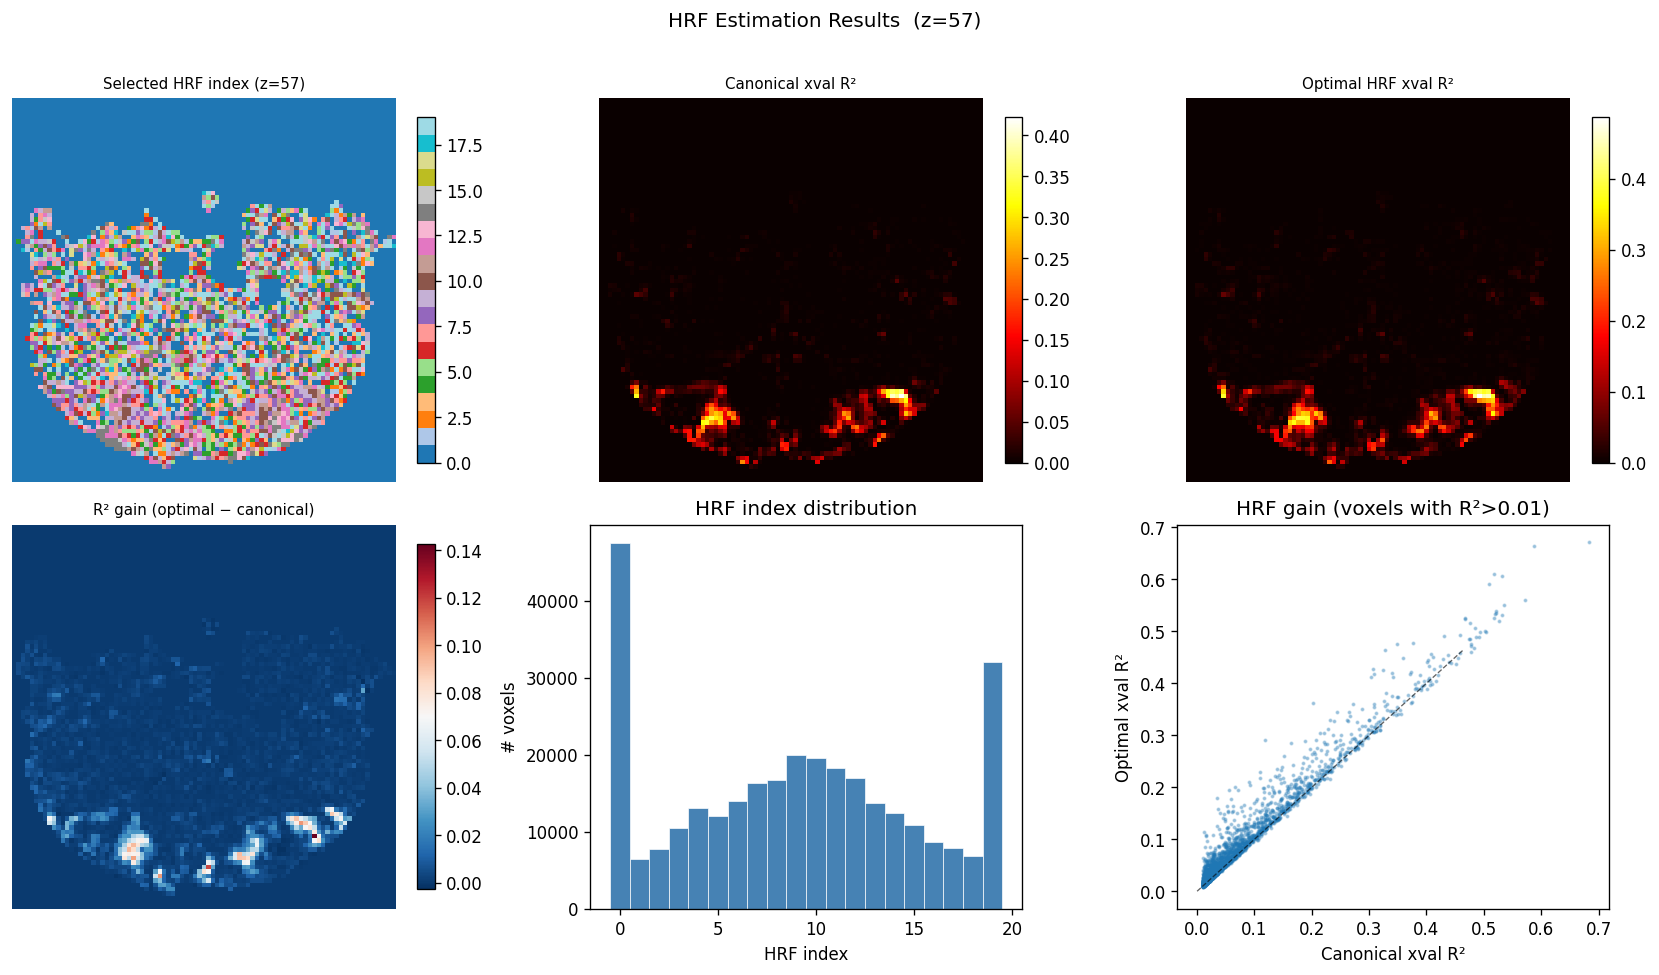

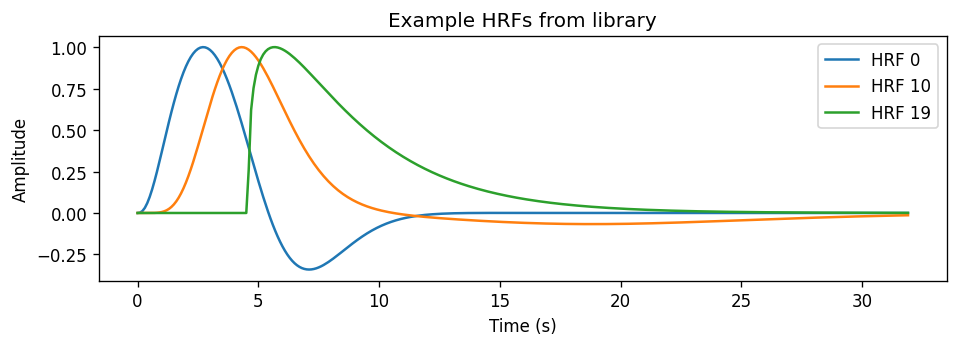

In [64]:
# ── HRF variability across the brain ─────────────────────────────────────────
# Tunable: change MID_SLICE to any slice index
MID_SLICE = vol_shape[2] // 2

def _to_vol(flat, shape, mask):
    """Restore flat masked array to full 3-D volume."""
    vol = np.full(int(np.prod(shape)), np.nan, dtype=np.float32)
    if mask is not None:
        vol[mask] = flat
    else:
        vol = flat
    return vol.reshape(shape)

hrf_vol       = _to_vol(hrf_index.numpy().astype(float), vol_shape, mask_flat)
canonical_vol = _to_vol(canonical_r2.numpy(), vol_shape, mask_flat)
hrfopt_vol    = _to_vol(hrfopt_r2.numpy(),    vol_shape, mask_flat)
gain_vol      = _to_vol(gain.numpy(),          vol_shape, mask_flat)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

def show_slice(ax, vol, title, cmap='hot', vmin=None, vmax=None):
    sl = vol[:, :, MID_SLICE].T
    im = ax.imshow(np.where(np.isnan(sl), 0, sl), origin='lower',
                   cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.04)
    ax.set_title(title, fontsize=9); ax.axis('off')

show_slice(axes[0, 0], hrf_vol, f'Selected HRF index (z={MID_SLICE})', cmap='tab20')
show_slice(axes[0, 1], canonical_vol, 'Canonical xval R²', cmap='hot', vmin=0)
show_slice(axes[0, 2], hrfopt_vol, 'Optimal HRF xval R²', cmap='hot', vmin=0)
show_slice(axes[1, 0], gain_vol, 'R² gain (optimal − canonical)', cmap='RdBu_r')

# Histogram of HRF index
ax = axes[1, 1]
ax.hist(hrf_index[hrf_index >= 0].numpy(), bins=N_HRFS, range=(-0.5, N_HRFS - 0.5),
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('HRF index'); ax.set_ylabel('# voxels')
ax.set_title('HRF index distribution')

# R² improvement scatter
ax = axes[1, 2]
pos = canonical_r2 > 0.01  # only voxels with some task signal
sub = slice(None, None, max(1, pos.sum().item() // 3000))
ax.scatter(canonical_r2[pos].numpy()[sub],
           hrfopt_r2[pos].numpy()[sub],
           s=2, alpha=0.3, rasterized=True)
lim = hrfopt_r2[pos].quantile(0.99).item()
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.6)
ax.set_xlabel('Canonical xval R²'); ax.set_ylabel('Optimal xval R²')
ax.set_title('HRF gain (voxels with R²>0.01)')

plt.suptitle(f'HRF Estimation Results  (z={MID_SLICE})', y=1.01)
plt.tight_layout(); plt.show()

# Show example HRF time-courses for 3 brain regions
# Tunable: pick any 3 indices to see example HRFs
show_hrf_indices = [0, N_HRFS // 2, N_HRFS - 1]
fig, ax = plt.subplots(figsize=(8, 3))
for idx in show_hrf_indices:
    ax.plot(t_hrf, hrf_library[idx].numpy(), label=f'HRF {idx}')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
ax.set_title('Example HRFs from library')
ax.legend()
plt.tight_layout(); plt.show()

---
## Section 3 — GLMdenoise Denoising

Noise-pool PCA (`GLMdenoise` style):
1. Identify **noise-pool voxels** (low task R²) and **criteria voxels** (high task R²).
2. Extract PCs from the noise pool, one run at a time.
3. Cross-validate (LORO): train on denoised data, test on raw → select optimal PC count.
4. Report how much the criteria-voxel xval R² improves.

In [ ]:
# Tunable thresholds
R2_THRESHOLD  = 0.0   # noise pool: R² < this; criteria: R² >= this
VARIANCE_THRESH = 0.05  # fraction of variance per PC (stopping criterion)

# TODO: Don't use the motion parameters as nuisance here. 

print('Running GLMdenoise-style denoising...')
denoise_results = fit_denoising_model(
    data                = data,
    design_matrix       = task_design,
    run_starts          = run_starts,
    tr                  = tr,
    r2_threshold        = R2_THRESHOLD,
    max_components      = MAX_NOISE_PCS,
    variance_threshold  = VARIANCE_THRESH,
    nuisance            = nuisance_per_run,
    polort              = -1,          # already in nuisance_per_run
    noise_method        = 'pca',
    device              = device,
    verbose             = True,
)

noise_pcs       = denoise_results.noise_pcs_per_run   # list of (n_tp_run, n_pcs)
optimal_pcs     = denoise_results.optimal_n_components
r2_by_pc        = denoise_results.xval_r2_by_n_components  # (n_pc_counts,) or 2D
noise_pool_mask = denoise_results.noise_pool_mask
initial_r2      = denoise_results.baseline_r2
xval_r2_optimal = denoise_results.optimal_r2     # (n_criteria_voxels,)

print(f'\nNoise pool:     {noise_pool_mask.sum().item():,} voxels')
print(f'Optimal PCs:    {optimal_pcs}')
print(f'Baseline median R²: {denoise_results.baseline_r2:.4f}')
print(f'Optimal median R²:  {denoise_results.optimal_r2:.4f}')
print(f'Improvement:        {denoise_results.improvement:+.4f}')

Running GLMdenoise-style denoising...

Cross-Validated Denoising Pipeline

Step 1: Computing cross-validated task-only R² for noise pool selection...
  (project-first nuisance removal, per run)


  Completed 9 CV folds (GLMdenoise-style concatenation)
  Median xval R²: 0.0010
  R² range: [-0.0394, 0.7317]

Step 2: Selecting noise pool (R² < 0.0) and criteria voxels...
  Noise pool: 121,926 voxels (39.1%)
  Criteria: 189,596 voxels (60.9%)
  Note: Criteria mask will be refined after computing per-PC R² maps
  Computed noise-pool PCA scree spectra (up to 60 components per run)

Step 3: Extracting PCs from noise pool (max=30, projecting 10 nuisance)...
  Run 1: 30 PCs (21.8% var, 10 nuisance projected)
  Run 2: 30 PCs (22.4% var, 10 nuisance projected)
  Run 3: 30 PCs (21.8% var, 10 nuisance projected)
  Run 4: 30 PCs (22.9% var, 10 nuisance projected)
  Run 5: 30 PCs (24.4% var, 10 nuisance projected)
  Run 6: 30 PCs (23.5% var, 10 nuisance projected)
  Run 7: 30 PCs (22.4% var, 10 nuisance projected)
  Run 8: 30 PCs (23.3% var, 10 nuisance projected)
  Run 9: 30 PCs (24.8% var, 10 nuisance projected)
  GPU memory after PCA: 4.07 GB allocated
  Moving data to CPU for cross-valida

Denoising CV: 100%|██████████| 4/4 [01:10<00:00, 17.75s/chunk]



R² computation complete
  Baseline (0 PCs): median R² = 0.0010
  Best (6 PCs): median R² = 0.0012
  Improvement: +0.0002
  Voxels with R² > 0 in any PC count: 216,011 / 311,522

Selecting optimal PC count:
  Criteria voxels (R² > 0.0 in any PC): 216,011 / 311,522
  Baseline (0 PCs): median R² = 0.0040
  Best (6 PCs): median R² = 0.0043
  Improvement: +0.0003

Full-brain cross-validated R² at optimal PC count (6 PCs):
  Valid voxels: 311,522
  Median R²: 0.0012
  Mean R²: 0.0178

✅ Denoising Complete
  Optimal: 6 PCs
  Baseline R²: 0.0010
  Optimal R²: 0.0012
  Improvement: +0.0002


Noise pool:     121,926 voxels
Optimal PCs:    6
Baseline median R²: 0.0010
Optimal median R²:  0.0012
Improvement:        +0.0002


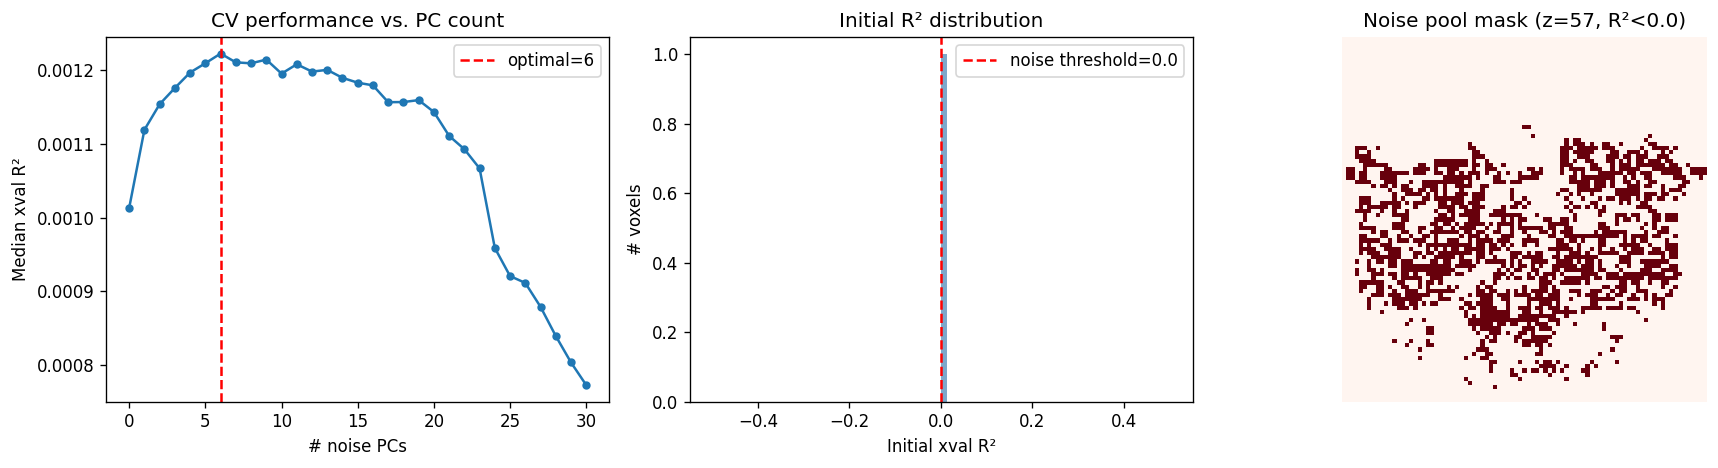

In [78]:
# ── Denoising diagnostics ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# CV curve
ax = axes[0]
if r2_by_pc is not None:
    r2_curve = r2_by_pc
    if r2_curve.ndim == 2:  # (n_folds, n_pcs) or (n_criteria, n_pcs)
        r2_curve = r2_curve.mean(0) if r2_curve.shape[0] > 1 else r2_curve[0]
    ax.plot(range(len(r2_curve)), r2_curve, 'o-', lw=1.5, markersize=4)
    ax.axvline(optimal_pcs, color='r', lw=1.5, linestyle='--',
               label=f'optimal={optimal_pcs}')
ax.set_xlabel('# noise PCs'); ax.set_ylabel('Median xval R²')
ax.set_title('CV performance vs. PC count')
ax.legend()

# Initial R² distribution
ax = axes[1]
if initial_r2 is not None:
    ir2 = initial_r2
    ax.hist(ir2, bins=80, color='steelblue', alpha=0.7)
    ax.axvline(R2_THRESHOLD, color='r', lw=1.5, linestyle='--',
               label=f'noise threshold={R2_THRESHOLD}')
ax.set_xlabel('Initial xval R²'); ax.set_ylabel('# voxels')
ax.set_title('Initial R² distribution')
ax.legend()

# Noise pool mask (one slice)
ax = axes[2]
pool_map = np.zeros(int(np.prod(vol_shape)), dtype=np.float32)
if mask_flat is not None:
    pool_map[mask_flat] = noise_pool_mask.cpu().float().numpy()
else:
    pool_map = noise_pool_mask.cpu().float().numpy()
ax.imshow(pool_map.reshape(vol_shape)[:, :, MID_SLICE].T,
          origin='lower', cmap='Reds', vmin=0, vmax=1)
ax.set_title(f'Noise pool mask (z={MID_SLICE}, R²<{R2_THRESHOLD})')
ax.axis('off')

plt.tight_layout(); plt.show()

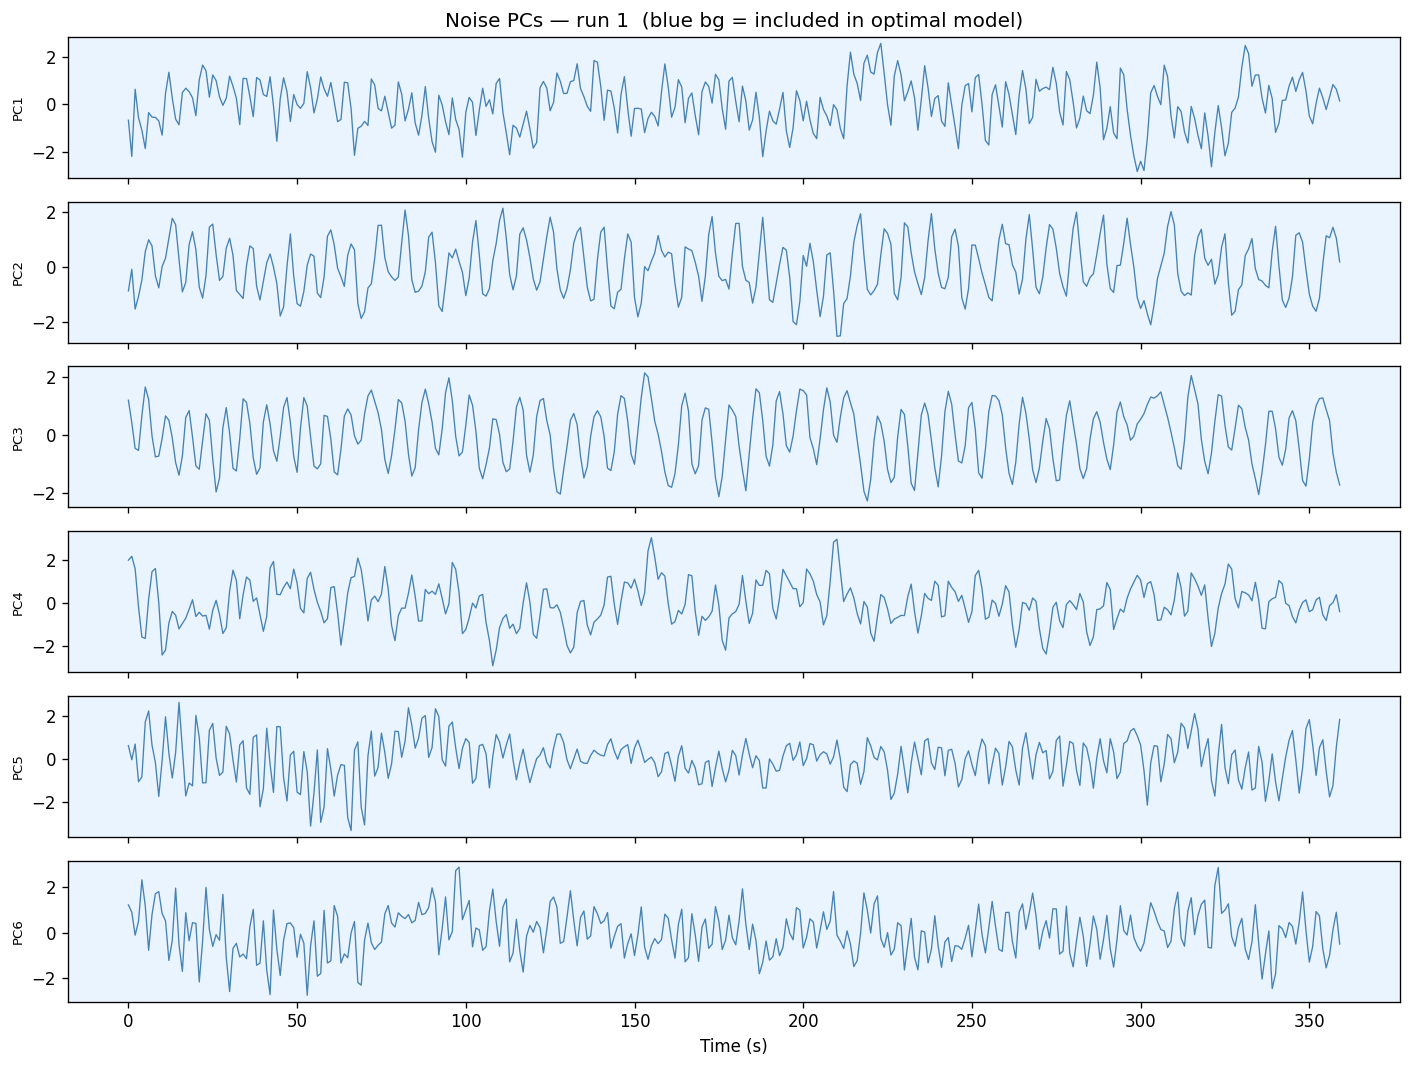

In [79]:
# ── Noise PC timecourses ───────────────────────────────────────────────────────
# Tunable: number of PCs to show and which run to inspect
N_PCS_SHOW = min(6, optimal_pcs if optimal_pcs > 0 else 6)
RUN_IDX    = 0

if noise_pcs and noise_pcs[RUN_IDX] is not None:
    pcs_run = noise_pcs[RUN_IDX].cpu().numpy()  # (n_tp_run, n_pcs)
    n_tp_run = pcs_run.shape[0]
    t_run = np.arange(n_tp_run) * tr

    fig, axes = plt.subplots(N_PCS_SHOW, 1, figsize=(12, 1.5 * N_PCS_SHOW), sharex=True)
    for i, ax in enumerate(axes):
        ax.plot(t_run, pcs_run[:, i], lw=0.8, color='steelblue')
        ax.set_ylabel(f'PC{i+1}', fontsize=8)
        # Mark as optimal if within optimal_pcs
        bg = '#eaf4ff' if i < optimal_pcs else 'white'
        ax.set_facecolor(bg)
    axes[0].set_title(f'Noise PCs — run {RUN_IDX+1}  (blue bg = included in optimal model)')
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout(); plt.show()
else:
    print('No noise PCs available for this run.')

---
## Section 4 — Whole-Brain ICA

Run **spatial ICA** on individual runs. Correlate IC timecourses with the task design
to find task-related and (if motion provided) motion-related components.

In [85]:
# ── ICA preprocessing + fitting ───────────────────────────────────────────────
# Tunable: which run to analyse
ICA_RUN_IDX = 0

start_tp = run_starts[ICA_RUN_IDX]
end_tp   = run_starts[ICA_RUN_IDX + 1] if ICA_RUN_IDX + 1 < n_runs else n_timepoints

# Extract this run:  (n_voxels, n_tp_run)
data_run = data[:, start_tp:end_tp].clone()  # CPU tensor

# Preprocess for ICA: polort projection + voxel variance normalisation
data_prep = apply_polort_projection(data_run, polort, device=device)   # (n_voxels, n_tp_run)
data_prep = apply_melodic_voxel_varnorm(data_prep)      # (n_voxels, n_tp_run)

# Auto-estimate component count (or use user-specified N_ICA_COMPS)
if N_ICA_COMPS is None:
    n_comps, _, _ = estimate_ica_component_count(
        data_vox_t          = data_run,        # (n_voxels, n_tp_run) CPU tensor
        method              = 'melodic',
        max_auto_components = MAX_NOISE_PCS,
        auto_min_components = 5,
        auto_var_threshold  = 0.9,
        use_mp_prior        = True,
        device              = device,
        verbose             = True,
    )
else:
    n_comps = N_ICA_COMPS
print(f'Using {n_comps} ICA components (run {ICA_RUN_IDX+1})')

# Run FastICA  — input is (n_timepoints, n_voxels) for spatial ICA
ica = FastICA(
    n_components = n_comps,
    fun          = 'logcosh',
    random_state = 42,
    device       = device,
)
ica_timeseries = ica.fit_transform(data_prep[0].T)  # (n_tp_run, n_comps)
# ica.components_  → (n_comps, n_voxels)  spatial maps (z-scored internally)
# ica.mixing_      → (n_tp_run, n_comps)  same as ica_timeseries

print(f'ICA done.  Timeseries: {ica_timeseries.shape}  Maps: {ica.components_.shape}')

    Component estimation: data (311,522 vox × 360 time)
    PCA for estimation: extracting 360 eigenvalues (component cap=30) ...
    PCA: 360 eigenvalues, 90%var@228, 99%var@345
    MP eigenvalue adjustment (MELODIC-style):
      360 raw eigs → drop 2 smallest → 358 eigs
      MP range: [0.9334, 1.0670] (nu=358/311522=0.00115)
      98% cumvar cutoff → 328 eigs retained
      Adjusted range: [5975.61, 2542230.70] (ratio=425.4×)
    Minka/MELODIC evidence scan: k in [5, 30] (n_samples=311,522, 328 adjusted eigs) ...
  ⚠ Minka first-peak was STILL INCREASING at k=30 (ceiling=30). True dimensionality may be higher. Consider increasing -max_auto_components.
    Minka selected k=30
Using 30 ICA components (run 1)
ICA done.  Timeseries: torch.Size([360, 30])  Maps: torch.Size([30, 311522])


tensor([[ 1.8268, -0.0913,  0.1897,  ..., -0.1558,  1.0687,  3.8843],
        [-0.4778, -0.0288, -0.1253,  ...,  2.4612,  2.8207,  0.5010],
        [ 0.4626,  2.1520, -0.5622,  ...,  1.8133,  0.8990,  1.4848],
        ...,
        [-1.2468, -0.6802,  1.2402,  ...,  0.1849, -0.5624, -0.2296],
        [-0.9544, -0.6880, -0.7722,  ...,  0.2844, -0.5060,  0.6775],
        [-1.5404, -1.3367,  0.8418,  ...,  0.1752, -1.8655,  0.9989]],
       device='cuda:0')

In [ ]:
# ── Correlate ICs with task design ────────────────────────────────────────────
# task_design_run: slice the task design for this run  (n_tp_run, n_conditions)
task_design_run = task_design[start_tp:end_tp, :]  # CPU tensor

# TODO: the task design should have the polynimals removed from it. 

# component_condition_correlations:  (n_comps, n_conditions)
corr_matrix = component_condition_correlations(
    mixing_tk = ica_timeseries,   # (n_tp_run, n_comps) tensor
    design_tc = task_design_run,  # (n_tp_run, n_conditions) tensor
)  # returns np.ndarray  (n_comps, n_conditions)

# Max absolute correlation per IC across conditions
max_task_corr = np.abs(corr_matrix).max(axis=1)  # (n_comps,)

# Sort ICs by task correlation (descending)
task_order   = np.argsort(-max_task_corr)
print('Top 5 task-correlated ICs:')
for rank, ic_idx in enumerate(task_order[:5]):
    cond_corrs = ', '.join([f'{CONDITION_LABELS[c]}={corr_matrix[ic_idx, c]:.3f}'
                             for c in range(n_conditions)])
    print(f'  Rank {rank+1}: IC {ic_idx+1:03d}  |  {cond_corrs}')

Top 5 task-correlated ICs:
  Rank 1: IC 017  |  Prompt=-0.544, Movie=0.807
  Rank 2: IC 025  |  Prompt=0.324, Movie=-0.411
  Rank 3: IC 003  |  Prompt=0.350, Movie=0.007
  Rank 4: IC 022  |  Prompt=-0.129, Movie=0.219
  Rank 5: IC 002  |  Prompt=0.209, Movie=-0.118


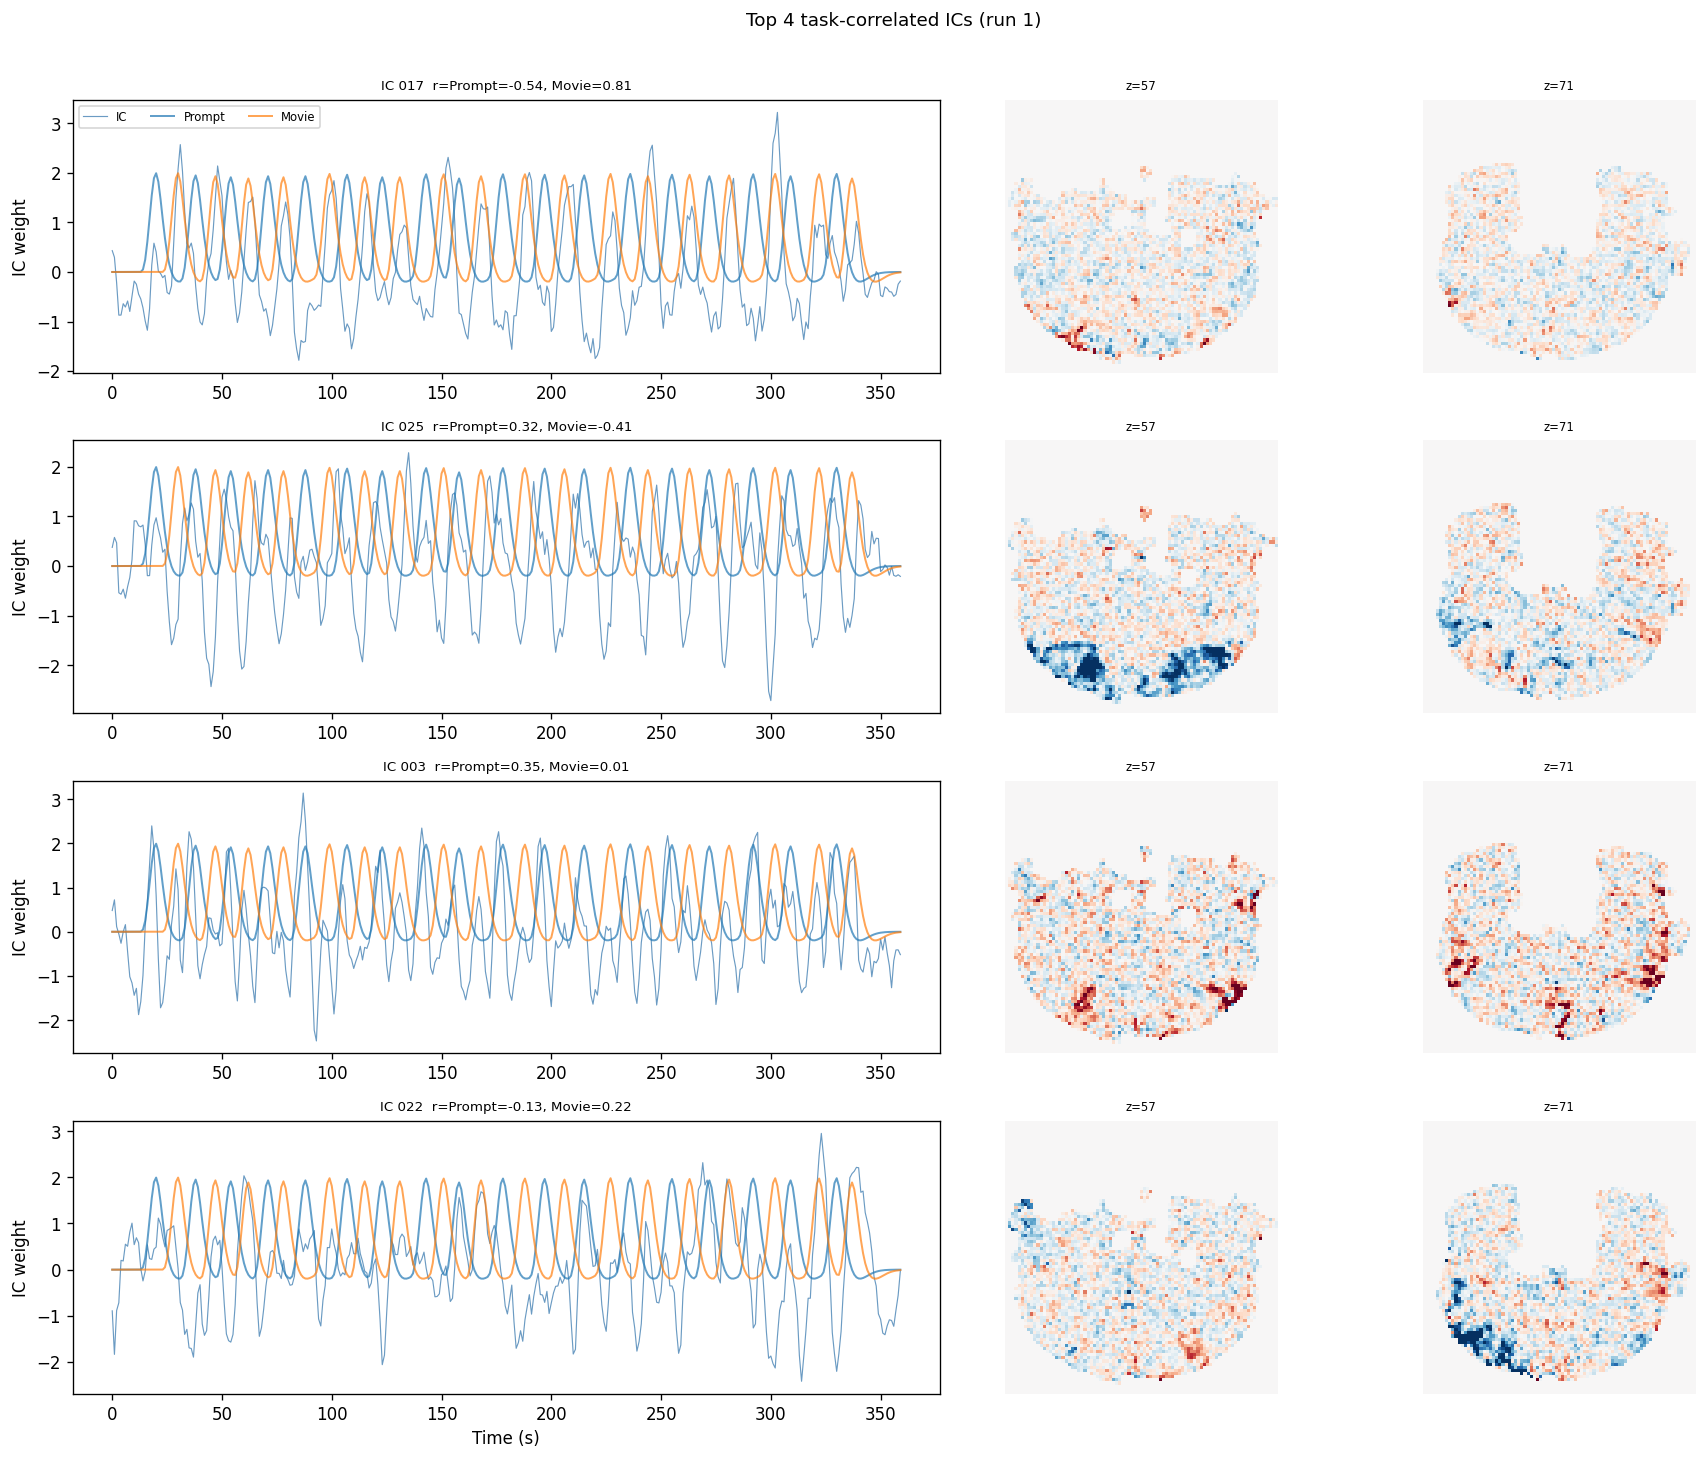

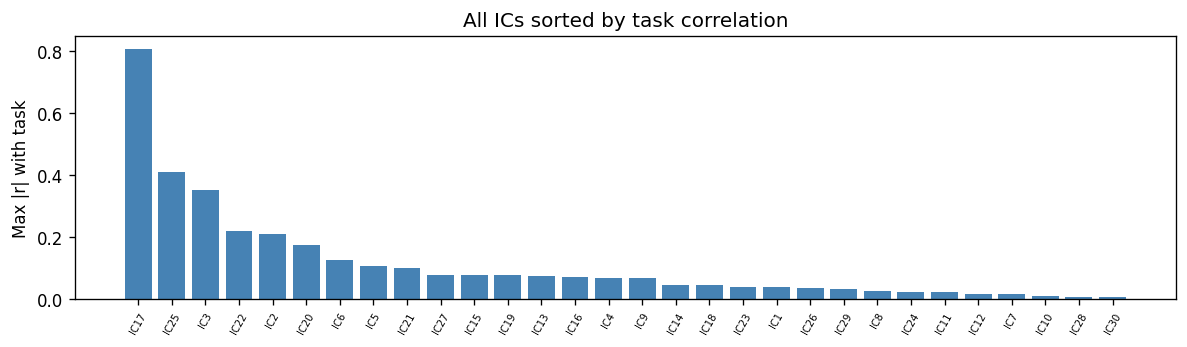

In [87]:
# ── Visualise top task-correlated ICs ─────────────────────────────────────────
# Tunable: how many ICs to show
N_ICS_SHOW = min(4, n_comps)
t_ica = np.arange(end_tp - start_tp) * tr

fig = plt.figure(figsize=(15, 3 * N_ICS_SHOW))
gs  = gridspec.GridSpec(N_ICS_SHOW, 3, figure=fig, width_ratios=[2, 1, 1])

ic_maps = ica.components_  # (n_comps, n_voxels), CPU or GPU tensor
if isinstance(ic_maps, torch.Tensor):
    ic_maps = ic_maps.cpu().numpy()

ica_tc = ica_timeseries
if isinstance(ica_tc, torch.Tensor):
    ica_tc = ica_tc.cpu().numpy()

for row, ic_idx in enumerate(task_order[:N_ICS_SHOW]):
    # Timecourse
    ax_tc = fig.add_subplot(gs[row, 0])
    ax_tc.plot(t_ica, ica_tc[:, ic_idx], lw=0.7, color='steelblue', alpha=0.8, label='IC')
    # Overlay task regressors (scaled to IC amplitude)
    for c in range(n_conditions):
        tc_norm = (task_design_run[:, c].numpy() *
                   np.std(ica_tc[:, ic_idx]) * 2)
        ax_tc.plot(t_ica, tc_norm, lw=1.2, alpha=0.7,
                   label=CONDITION_LABELS[c])
    cstr = ', '.join([f'{CONDITION_LABELS[c]}={corr_matrix[ic_idx, c]:.2f}'
                      for c in range(n_conditions)])
    ax_tc.set_title(f'IC {ic_idx+1:03d}  r={cstr}', fontsize=8)
    ax_tc.set_ylabel('IC weight')
    if row == 0:
        ax_tc.legend(fontsize=7, ncol=n_conditions + 1)
    if row == N_ICS_SHOW - 1:
        ax_tc.set_xlabel('Time (s)')

    # Spatial map: two slices
    ic_flat = np.zeros(int(np.prod(vol_shape)), dtype=np.float32)
    if mask_flat is not None:
        ic_flat[mask_flat] = ic_maps[ic_idx]
    else:
        ic_flat = ic_maps[ic_idx]
    ic_vol = ic_flat.reshape(vol_shape)
    clim = np.percentile(np.abs(ic_vol), 99.5)

    for col, slice_z in enumerate([MID_SLICE, MID_SLICE + vol_shape[2] // 8], start=1):
        ax_sl = fig.add_subplot(gs[row, col])
        slice_z = max(0, min(slice_z, vol_shape[2] - 1))
        ax_sl.imshow(ic_vol[:, :, slice_z].T, origin='lower',
                     cmap='RdBu_r', vmin=-clim, vmax=clim)
        ax_sl.set_title(f'z={slice_z}', fontsize=7)
        ax_sl.axis('off')

plt.suptitle(f'Top {N_ICS_SHOW} task-correlated ICs (run {ICA_RUN_IDX+1})',
             fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

# Summary bar chart of all ICs sorted by task correlation
fig, ax = plt.subplots(figsize=(max(8, n_comps // 3), 3))
bars = ax.bar(range(n_comps), max_task_corr[task_order],
              color='steelblue', edgecolor='none')
ax.set_xticks(range(n_comps))
ax.set_xticklabels([f'IC{task_order[i]+1}' for i in range(n_comps)],
                   rotation=60, fontsize=6)
ax.set_ylabel('Max |r| with task')
ax.set_title('All ICs sorted by task correlation')
plt.tight_layout(); plt.show()

Highest motion IC: IC 029  max |r|=0.963


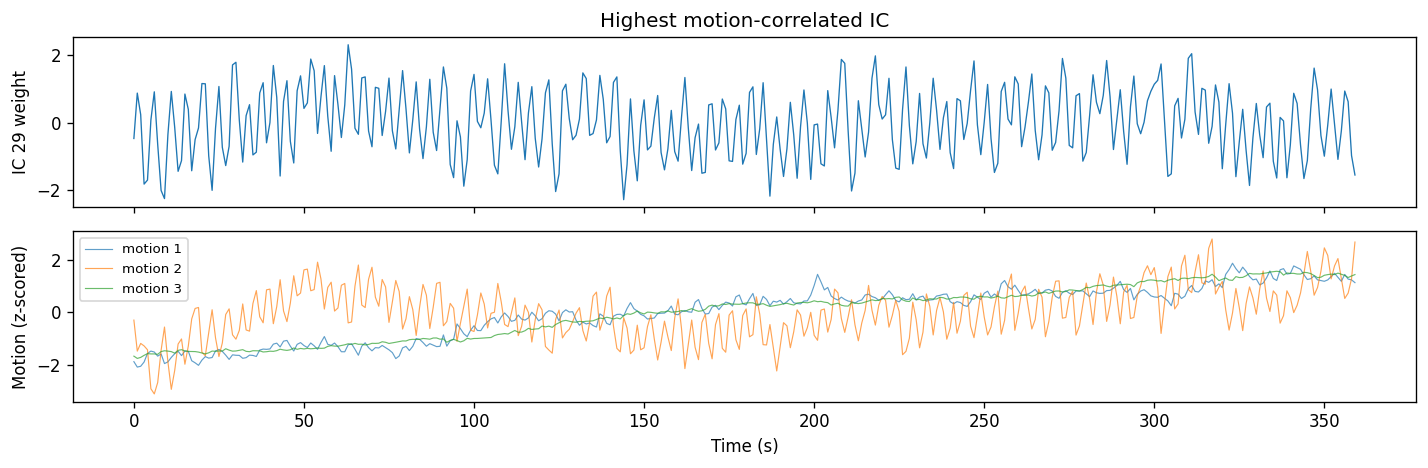

In [ ]:
# ── Motion IC (if ortvec provided) ────────────────────────────────────────────
if ORTVEC_FILE is not None:
    from fastfuncsim.hrf_selection import load_nuisance_file
    motion = load_nuisance_file(ORTVEC_FILE, expected_rows=n_timepoints)  # (n_tp, n_motion)
    motion_run = motion[start_tp:end_tp, :]  # slice to this run
    if not isinstance(motion_run, torch.Tensor):
        motion_run = torch.as_tensor(np.asarray(motion_run), dtype=torch.float32)
    # TODO we must project out the polynomials from the motion (and only the polynomials).
    # Correlate ICs with each motion parameter
    motion_corr = component_condition_correlations(
        mixing_tk = ica_timeseries,  # (n_tp_run, n_comps) tensor
        design_tc = motion_run,      # (n_tp_run, n_motion) tensor
    )  # (n_comps, n_motion)
    max_motion_corr  = np.abs(motion_corr).max(axis=1)  # (n_comps,)
    top_motion_ic    = np.argmax(max_motion_corr)

    print(f'Highest motion IC: IC {top_motion_ic+1:03d}  '
          f'max |r|={max_motion_corr[top_motion_ic]:.3f}')

    fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
    axes[0].plot(t_ica, ica_tc[:, top_motion_ic], lw=0.8)
    axes[0].set_ylabel(f'IC {top_motion_ic+1} weight')
    axes[0].set_title('Highest motion-correlated IC')

    for m in range(min(3, motion_run.shape[1])):
        m_ts = motion_run[:, m].numpy() if isinstance(motion_run, torch.Tensor) else motion_run[:, m]
        axes[1].plot(t_ica,
                     (m_ts - m_ts.mean()) / (m_ts.std() + 1e-8),
                     lw=0.7, alpha=0.7, label=f'motion {m+1}')
    axes[1].set_ylabel('Motion (z-scored)'); axes[1].set_xlabel('Time (s)')
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print('(No ORTVEC_FILE provided — skipping motion IC section.)')

---
## Section 5 — Ridge Regression / Single-Trial Betas

Each event gets its own beta estimate (GLMsingle style). Ridge regularisation is
selected per voxel via beta-space CV. We then compare single-trial beta distributions
between a **high-R² voxel** and a **low-R² voxel**.

In [89]:
# ── Build single-trial design ─────────────────────────────────────────────────
print('Building single-trial design...')
(
    st_design,           # (n_timepoints, n_trials)
    trial_labels,        # List[str]
    trial_condition_ids, # (n_trials,) int: which condition
    trial_run_ids,       # (n_trials,) int: which run
    condition_design,    # (n_timepoints, n_conditions)
) = create_single_trial_design(
    onsets_by_condition = all_onsets,
    durations           = stim_durations,
    run_starts          = run_starts,
    tr                  = tr,
    n_timepoints        = n_timepoints,
    hrf_library         = [canonical_hrf],  # single HRF for all voxels
    microtime_dt        = DT,
    condition_labels    = CONDITION_LABELS,
    device              = torch.device('cpu'),
)
n_trials = st_design.shape[1]
print(f'Trials: {n_trials}  Design: {st_design.shape}')
print(f'Conditions per trial: {torch.unique(trial_condition_ids).tolist()}')

Building single-trial design...
Trials: 324  Design: torch.Size([3240, 324])
Conditions per trial: [0, 1]


In [90]:
# ── Project nuisance from data + design ──────────────────────────────────────
print('Projecting nuisance from data and single-trial design...')
data_clean, design_clean = project_out_nuisance_per_run(
    data             = data,
    design           = st_design,        # correct param name (not design_matrix)
    nuisance_per_run = nuisance_per_run,
    run_starts       = run_starts,
    device           = device,
)
design_clean_dev = design_clean.to(device)
print(f'Projected data: {data_clean.shape}  design: {design_clean.shape}')

# ── Ridge fraction grid ───────────────────────────────────────────────────────
frac_start, frac_end, frac_step = RIDGE_FRAC_GRID
fracs = np.arange(frac_start, frac_end + frac_step / 2, frac_step, dtype=np.float32)
n_fracs = len(fracs)
print(f'Ridge fracs: {n_fracs}  range=[{fracs[0]:.2f}, {fracs[-1]:.2f}]')

# ── CV splits (LORO) ─────────────────────────────────────────────────────────
cv_splits = generate_cv_splits(n_runs, strategy=1)

# ── Fit ridge + beta-space CV (chunked) ───────────────────────────────────────
print('Fitting ridge regression with beta-space CV...')
final_betas   = torch.zeros(n_voxels, n_trials)
xval_r2       = torch.zeros(n_voxels)
full_r2       = torch.zeros(n_voxels)
optimal_fracs = torch.zeros(n_voxels)
r2_by_frac    = torch.zeros(n_voxels, n_fracs)

for c0 in range(0, n_voxels, CHUNK_SIZE):
    c1        = min(c0 + CHUNK_SIZE, n_voxels)
    data_chunk = data_clean[c0:c1]  # (chunk, n_tp) — on CPU

    # Fit all fracs for this chunk
    chunk_coefs = _fit_ridge_multiple_fracs(
        design_clean_dev, data_chunk.T, fracs, device, chunk_size=None,
    )  # (n_trials, n_fracs, chunk) on device

    # Beta-space CV (GLMsingle pattern: test against OLS = last frac)
    chunk_betas_all = chunk_coefs.permute(1, 2, 0)  # (n_fracs, chunk, n_trials)
    xval_out = single_trial_cv_helper(
        chunk_betas_all, trial_condition_ids, trial_run_ids, cv_splits,
        test_variant_idx = n_fracs - 1,
        device=device, verbose=False,
    )
    chunk_r2_frac = xval_out['r2'].T  # (chunk, n_fracs) on device

    # Select best frac (exclude frac=1.0 = OLS itself)
    chunk_xval, chunk_best_idx = chunk_r2_frac[:, :-1].max(dim=1)
    xval_r2[c0:c1]    = chunk_xval.cpu()
    r2_by_frac[c0:c1] = chunk_r2_frac.cpu()
    optimal_fracs[c0:c1] = torch.from_numpy(fracs[chunk_best_idx.cpu().numpy()])

    # Final betas at optimal fraction
    vox_idx    = torch.arange(c1 - c0, device=device)
    chunk_final = chunk_coefs[:, chunk_best_idx, vox_idx].T  # (chunk, n_trials)
    final_betas[c0:c1] = chunk_final.cpu()
    del chunk_coefs

    # Full-model R² (task variance in projected data)
    predicted = final_betas[c0:c1].to(device) @ design_clean_dev.T
    full_r2[c0:c1] = compute_r2_metric(data_chunk.to(device), predicted, metric='cod').cpu()

    if (c0 // CHUNK_SIZE) % 5 == 0:
        pct = 100 * c1 / n_voxels
        print(f'  {pct:4.0f}%  vox {c0}–{c1}')

print(f'\nBeta-space CV R²:  mean={xval_r2.mean():.4f}  median={xval_r2.median():.4f}')
print(f'Full-model R²:     mean={full_r2.mean():.4f}  median={full_r2.median():.4f}')

Projecting nuisance from data and single-trial design...
Projected data: torch.Size([311522, 3240])  design: torch.Size([3240, 324])
Ridge fracs: 20  range=[0.05, 1.00]
Fitting ridge regression with beta-space CV...
    16%  vox 0–50000
    96%  vox 250000–300000

Beta-space CV R²:  mean=0.0166  median=-0.0024
Full-model R²:     mean=0.1494  median=0.1243


High-R² voxel: 231089  xval_R²=0.444  opt_frac=0.95
Low-R²  voxel: 166802   xval_R²=0.032  opt_frac=0.45


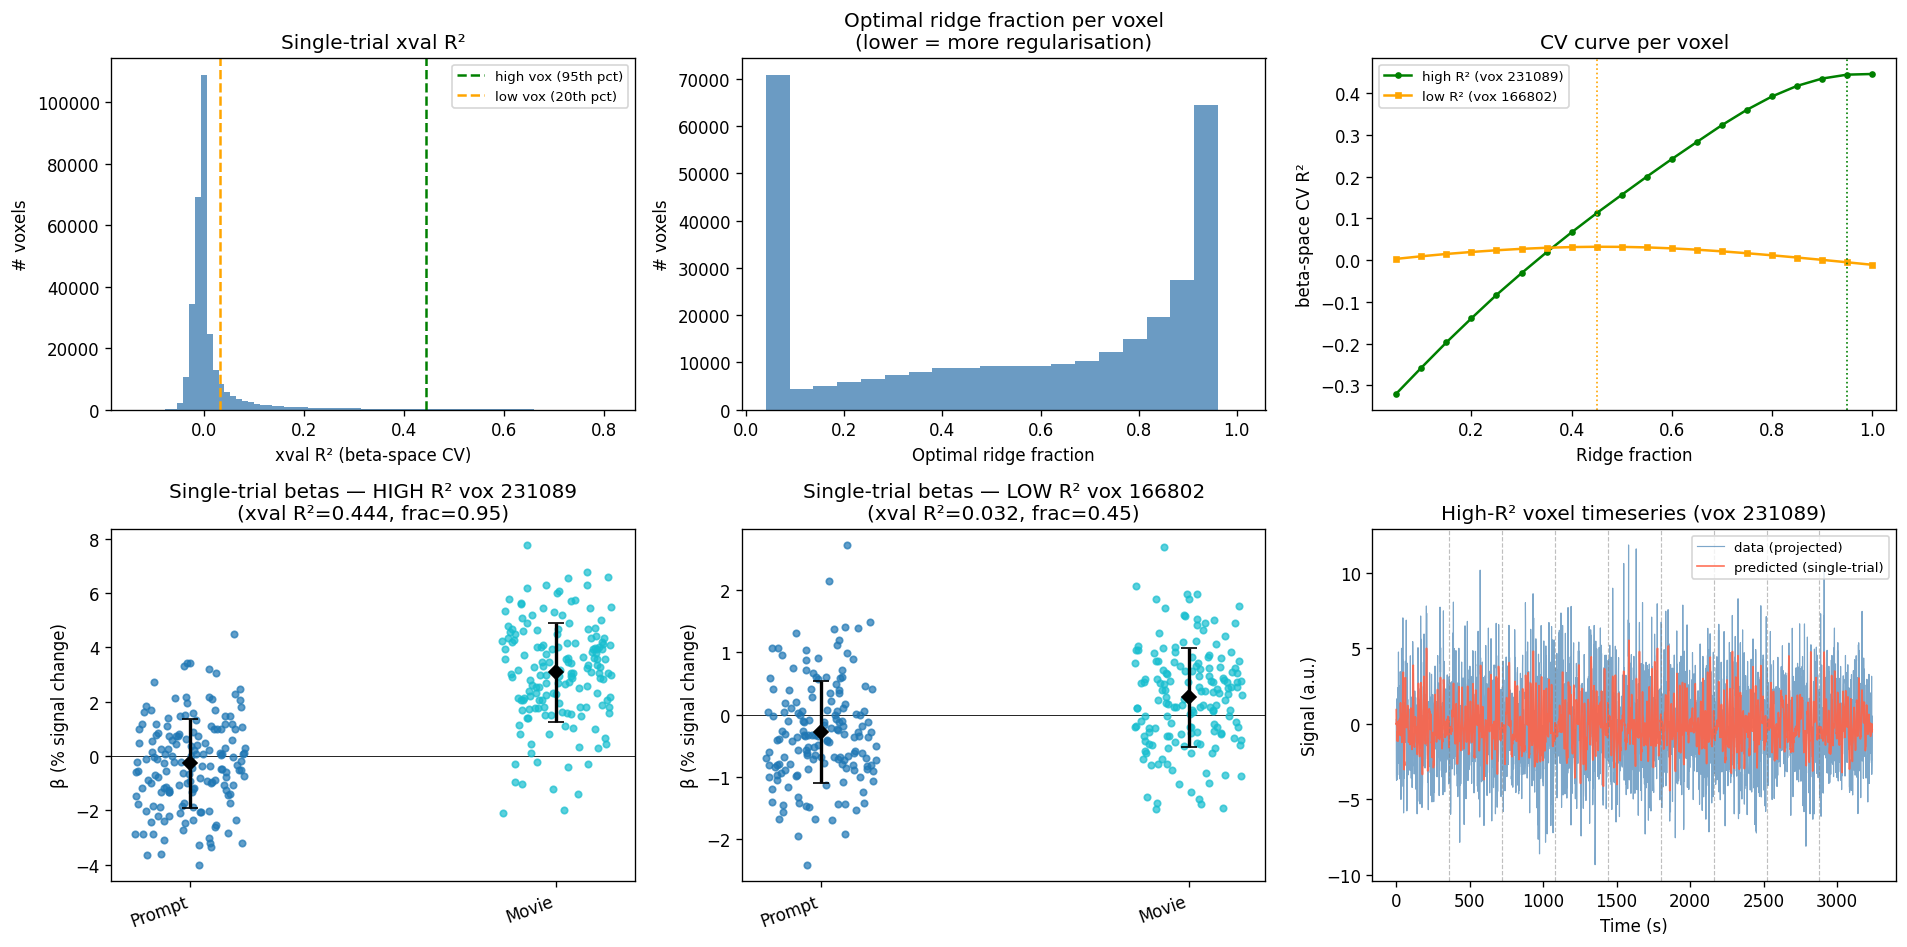

In [91]:
# ── Compare high-R² vs low-R² voxel single-trial betas ───────────────────────
# Tunable: R² percentiles to select example voxels
HIGH_R2_PCT = 95   # top percentile
LOW_R2_PCT  = 20   # low-but-non-zero percentile

# Only consider voxels with positive initial signal
valid = xval_r2 > 0.02
if valid.sum() < 10:
    print('Too few positive-R² voxels — lowering threshold to 0')
    valid = torch.ones(n_voxels, dtype=torch.bool)

r2_valid = xval_r2[valid]
idx_valid = torch.where(valid)[0]

high_thresh = float(torch.quantile(r2_valid, HIGH_R2_PCT / 100))
low_thresh  = float(torch.quantile(r2_valid, LOW_R2_PCT / 100))

# Pick representative voxels (closest to each threshold)
high_vox = idx_valid[(r2_valid - high_thresh).abs().argmin()].item()
low_vox  = idx_valid[(r2_valid - low_thresh ).abs().argmin()].item()

print(f'High-R² voxel: {high_vox}  xval_R²={xval_r2[high_vox]:.3f}  '
      f'opt_frac={optimal_fracs[high_vox]:.2f}')
print(f'Low-R²  voxel: {low_vox}   xval_R²={xval_r2[low_vox]:.3f}  '
      f'opt_frac={optimal_fracs[low_vox]:.2f}')

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# --- xval R² distributions ---
ax = axes[0, 0]
ax.hist(xval_r2.numpy(), bins=80, color='steelblue', alpha=0.8)
ax.axvline(xval_r2[high_vox].item(), color='green',  lw=1.5,
           linestyle='--', label=f'high vox ({HIGH_R2_PCT}th pct)')
ax.axvline(xval_r2[low_vox].item(),  color='orange', lw=1.5,
           linestyle='--', label=f'low vox ({LOW_R2_PCT}th pct)')
ax.set_xlabel('xval R² (beta-space CV)'); ax.set_ylabel('# voxels')
ax.set_title('Single-trial xval R²'); ax.legend(fontsize=8)

# --- Optimal ridge fraction distribution ---
ax = axes[0, 1]
ax.hist(optimal_fracs.numpy(), bins=n_fracs, range=(fracs[0] - 0.01, fracs[-1] + 0.01),
        color='steelblue', alpha=0.8)
ax.set_xlabel('Optimal ridge fraction'); ax.set_ylabel('# voxels')
ax.set_title('Optimal ridge fraction per voxel\n(lower = more regularisation)')

# --- R² by fraction (two example voxels) ---
ax = axes[0, 2]
ax.plot(fracs, r2_by_frac[high_vox].numpy(), 'o-', color='green',  lw=1.5,
        markersize=3, label=f'high R² (vox {high_vox})')
ax.plot(fracs, r2_by_frac[low_vox].numpy(),  's-', color='orange', lw=1.5,
        markersize=3, label=f'low R² (vox {low_vox})')
ax.axvline(optimal_fracs[high_vox].item(), color='green',  lw=1, linestyle=':')
ax.axvline(optimal_fracs[low_vox].item(),  color='orange', lw=1, linestyle=':')
ax.set_xlabel('Ridge fraction'); ax.set_ylabel('beta-space CV R²')
ax.set_title('CV curve per voxel'); ax.legend(fontsize=8)

# --- Single-trial betas, high-R² voxel (per condition) ---
ax = axes[1, 0]
conds = CONDITION_LABELS
colors = plt.cm.tab10(np.linspace(0, 1, n_conditions))
for c_idx, (_cond, color) in enumerate(zip(conds, colors, strict=False)):
    mask_c = trial_condition_ids == c_idx
    betas_c = final_betas[high_vox, mask_c].numpy()
    x_jitter = c_idx + np.random.uniform(-0.15, 0.15, len(betas_c))
    ax.scatter(x_jitter, betas_c, s=15, color=color, alpha=0.7, zorder=3)
    ax.errorbar(c_idx, betas_c.mean(), yerr=betas_c.std(),
                fmt='D', color='black', markersize=6, lw=2, capsize=5, zorder=4)
ax.set_xticks(range(n_conditions))
ax.set_xticklabels(conds, rotation=20, ha='right')
ax.set_ylabel('β (% signal change)')
ax.set_title(f'Single-trial betas — HIGH R² vox {high_vox}\n'
             f'(xval R²={xval_r2[high_vox]:.3f}, frac={optimal_fracs[high_vox]:.2f})')
ax.axhline(0, color='k', lw=0.5)

# --- Single-trial betas, low-R² voxel ---
ax = axes[1, 1]
for c_idx, (_cond, color) in enumerate(zip(conds, colors, strict=False)):
    mask_c = trial_condition_ids == c_idx
    betas_c = final_betas[low_vox, mask_c].numpy()
    x_jitter = c_idx + np.random.uniform(-0.15, 0.15, len(betas_c))
    ax.scatter(x_jitter, betas_c, s=15, color=color, alpha=0.7, zorder=3)
    ax.errorbar(c_idx, betas_c.mean(), yerr=betas_c.std(),
                fmt='D', color='black', markersize=6, lw=2, capsize=5, zorder=4)
ax.set_xticks(range(n_conditions))
ax.set_xticklabels(conds, rotation=20, ha='right')
ax.set_ylabel('β (% signal change)')
ax.set_title(f'Single-trial betas — LOW R² vox {low_vox}\n'
             f'(xval R²={xval_r2[low_vox]:.3f}, frac={optimal_fracs[low_vox]:.2f})')
ax.axhline(0, color='k', lw=0.5)

# --- Overlay timeseries (high vox): data vs predicted ---
ax = axes[1, 2]
# Reconstruct predicted timeseries from single-trial betas
pred_ts = (final_betas[[high_vox]].to(device) @ design_clean_dev.T).squeeze().cpu().numpy()
t_all   = np.arange(n_timepoints) * tr
raw_ts  = data_clean[high_vox].numpy()
ax.plot(t_all, raw_ts,  lw=0.7, alpha=0.7, label='data (projected)', color='steelblue')
ax.plot(t_all, pred_ts, lw=1.0, alpha=0.9, label='predicted (single-trial)', color='tomato')
for rs in run_starts[1:]:
    ax.axvline(rs * tr, color='gray', lw=0.7, linestyle='--', alpha=0.5)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Signal (a.u.)')
ax.set_title(f'High-R² voxel timeseries (vox {high_vox})')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

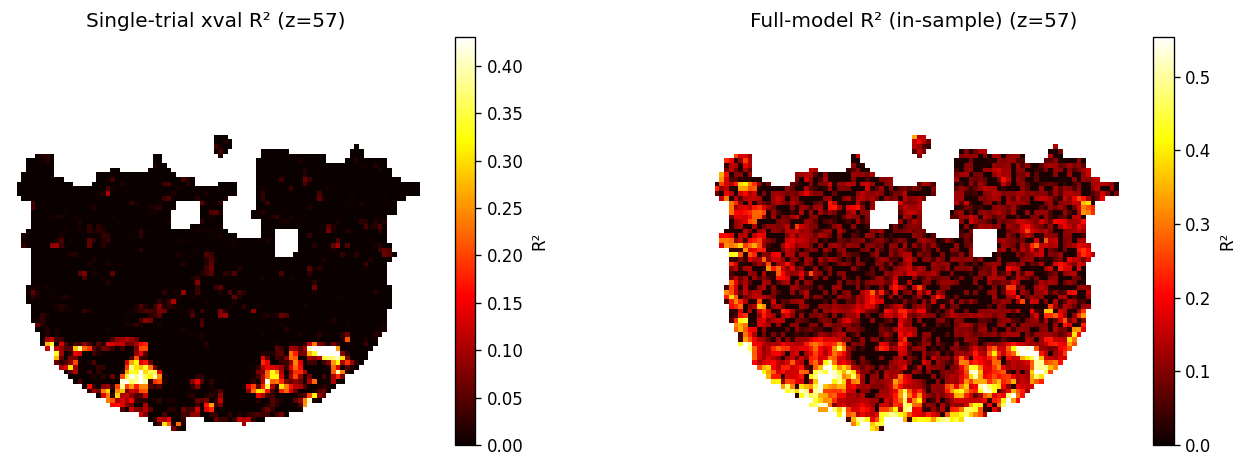

Done — all sections complete.


In [92]:
# ── Full-brain xval R² map ─────────────────────────────────────────────────────
# Tunable: MID_SLICE (already defined above), can change here if desired
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (r2_flat, title) in zip(axes, [
    (xval_r2.numpy(), 'Single-trial xval R²'),
    (full_r2.numpy(), 'Full-model R² (in-sample)'),
], strict=False):
    vol = _to_vol(r2_flat, vol_shape, mask_flat)
    im  = ax.imshow(vol[:, :, MID_SLICE].T, origin='lower',
                    cmap='hot', vmin=0, vmax=np.nanpercentile(vol, 99))
    plt.colorbar(im, ax=ax, label='R²')
    ax.set_title(f'{title} (z={MID_SLICE})')
    ax.axis('off')

plt.tight_layout()
plt.show()
print('Done — all sections complete.')